<center><span style="font-size:50px;"><b>ANALYSIS OF CUTS ON MC - PAIR VARIABLES</b></span></center>

In this notebook we want to search for the best cuts of the Monte Carlo data, in order to try them later in real data.  
Here we focus in the distribution and possible cuts of the pair variables.

The codes in the pdg for the important particles are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

---

---

<center><span style="font-size:35px;"><b>UPLOADING DATA</b></span></center>

#### ALL OUR DATA

In [96]:
# %%bash
# ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

#### UPLOAD DATA
Let's upload the data while:
* substituting (or rather summarizing them) the columns of MC info with a single column telling us who is D0 (1), who anti-D0 (-1) and who background (0)

In [97]:
# directory where the files are stored
folder = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"
all_files = glob.glob(os.path.join(folder, "*.pkl"))
# choose eventually which columns to exclude:
# useless_cols = ["neg_pt", "pos_pt"]
useless_cols = []

# choose how many files to load
x = 37                              # change this to the number of files you want (or your RAM can afford..)
files_to_load = all_files[:x]

print(f"Found {len(all_files)} files. Loading up to {len(files_to_load)} files")

Found 57 files. Loading up to 37 files


In [98]:
# initialization
final_results = pd.DataFrame()
upload_type = "ready_dataframe"

if  upload_type=="ready_dataframe":
    
    # final_results = pd.read_pickle("/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs_concatenated/ALL_MC.pkl")
    final_results = pd.read_pickle("/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs_concatenated/concatenated_pairs.pkl")


elif upload_type=="from_pkl_files":


    # UPLOAD ---------------------------------------------------------------------
    for i, f in enumerate(files_to_load, start=1):
        
        # UPLOAD DATA excluding useless columns:
        df = pd.read_pickle(f)
        df = df.drop(columns=useless_cols)
    
        # DEFINING MASKS to decrease the number of columns by summarizing them:
        mask_true_d0 = (
            (df["track_pdg_pos"] == 211 ) &
            (df["track_pdg_neg"] == -321 ) &
            (df["mother_pdg_pos"] == 421) &
            (df["mother_pdg_neg"] == 421) &
            (df["beauty_pdg_pos"] == 0) &
            (df["beauty_pdg_neg"] == 0) &
            (df["mother_N_final_state_pos"] == 2) &
            (df["mother_N_final_state_neg"] == 2) &
            (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
        )
        mask_true_anti_d0 = (
            (df["track_pdg_pos"] == 321) &
            (df["track_pdg_neg"] == -211) &
            (df["mother_pdg_pos"] == -421) &
            (df["mother_pdg_neg"] == -421) &
            (df["beauty_pdg_pos"] == 0) &
            (df["beauty_pdg_neg"] == 0) &
            (df["mother_N_final_state_pos"] == 2) &
            (df["mother_N_final_state_neg"] == 2) &
            (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
        )
        # mask_background = ( (~mask_true_d0) & (~mask_true_anti_d0) )
    
        # SUMMARIZE some columns:
        df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0] , [1, -1], default=0)
        summarized_cols = ["track_pdg_pos", "track_pdg_neg", "mother_pdg_pos", "mother_pdg_neg", "beauty_pdg_pos", "beauty_pdg_neg",
                         "mother_N_final_state_pos", "mother_N_final_state_neg", "mother_orig_ind_pos", "mother_orig_ind_neg"]
        df = df.drop(columns=summarized_cols)
    
        # FINAL single file uploaded:
        final_results = pd.concat([final_results, df], ignore_index=True)
        
        # free memory
        del df
        gc.collect()
        
        # debug
        print(f"{i}", end=' ')
    
    print(f"\nFinished: loaded {i} files out of {len(all_files)} available.")

In [99]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 33_559_115 rows and 19 columns.
It occupies 4_864.68 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,pos_pt,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,truth
0,-0.001307,1.647857,1.449501,1.590537,2.064567,0.378364,0.443343,-6.947757,133.719315,-0.093189,1.610355,-1.825205,6352.559082,0.014020,0.260088,951.74823,-0.417602,587.019836,0
1,-0.007081,0.947897,0.935076,0.698830,5.386100,-0.238735,0.443343,-6.947757,133.719315,-0.093189,0.493763,-0.913118,-1072.173340,0.075984,0.260088,951.74823,-6.905696,-147.886261,0
2,0.005584,0.813485,0.819674,0.772823,3.091237,0.265503,0.443343,-6.947757,133.719315,-0.093189,0.334891,1.178568,-999.000000,-0.059924,0.260088,951.74823,-6.446581,-999.000000,0
3,-0.016409,0.966982,0.953821,0.597828,3.955609,-0.544734,0.443343,-6.947757,133.719315,-0.093189,0.436598,69.200188,-999.000000,0.176080,0.260088,951.74823,24.368649,-999.000000,0
4,0.015970,1.400717,1.328300,0.452560,3.330226,0.408916,0.443343,-6.947757,133.719315,-0.093189,0.725583,-0.713104,-999.000000,-0.171371,0.260088,951.74823,-2.782018,-999.000000,0
33559110,0.005797,2.215586,2.349841,1.603195,5.040483,0.580255,1.695436,3.369998,-999.000000,-0.057284,0.542256,4.806453,-999.000000,-0.101200,0.662967,-999.00000,-0.686590,-999.000000,0
33559111,0.003031,1.345027,1.523370,2.034932,4.888945,0.676868,1.695436,3.369998,-999.000000,-0.057284,0.652135,17.760324,-999.000000,-0.052913,0.662967,-999.00000,12.176058,-999.000000,0
33559112,-0.000250,0.977256,0.963100,0.810587,5.902689,0.008033,0.386838,-7.404598,-999.000000,0.030822,0.427131,-0.734404,-1280.860474,-0.008111,0.154869,-999.00000,-7.097054,-158.802521,0
33559113,-0.003119,1.301705,1.269090,0.414444,5.871413,-0.085804,0.386838,-7.404598,-999.000000,0.030822,0.542256,4.806453,-999.000000,-0.101200,0.154869,-999.00000,-0.686590,-999.000000,0
33559114,-0.001631,1.265969,1.205582,0.274962,5.847783,0.944077,0.386838,-7.404598,-999.000000,0.030822,0.652135,17.760324,-999.000000,-0.052913,0.154869,-999.00000,12.176058,-999.000000,0


In [100]:
# final_results.to_pickle("/home/benedetto/Scrivania/LCP_B/project/concatenated_pairs.pkl")

---

## TRUE $D_0$ IN OUR DATA

In [101]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0_start = ( final_results["truth"] == 1 )
mask_true_anti_d0_start = ( final_results["truth"] == -1 )
mask_signal_start = ( (mask_true_d0_start) | (mask_true_anti_d0_start) )
mask_background_start = ( final_results["truth"] == 0 )

d0_tot_start = np.sum( mask_true_d0_start )
anti_d0_tot_start = np.sum( mask_true_anti_d0_start )
signal_tot_start = d0_tot_start + anti_d0_tot_start
num_bg_pairs_start = np.sum( mask_background_start )
farction_of_signal_start = (d0_tot_start + anti_d0_tot_start) / len(final_results) * 100

print("======== STATISTICS FOR STARTING PAIR DATAFRAME (NO CUTS) ========= \n")
print(f"Number of D0:               ", d0_tot_start )
print(f"Number of anti-D0:          ", anti_d0_tot_start )
print(f"Number of signal particles: ", signal_tot_start )
print(f"Number of background pairs: {num_bg_pairs_start:_}")
print(f"Fraction of D0 and anti-D0 over total: {farction_of_signal_start:.4f}%"  )

======== STATISTICS FOR STARTING PAIR DATAFRAME (NO CUTS) ========= 

Number of D0:                6452
Number of anti-D0:           6718
Number of signal particles:  13170
Number of background pairs: 33_545_945
Fraction of D0 and anti-D0 over total: 0.0392%


The variables we have to work with are:

In [102]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_pt', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY',
       'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi',
       'neg_TOFpi', 'pos_TPCka', 'pos_TOFka', 'truth'],
      dtype='object')


Example: the variable 'neg_TOFka' refers to the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which will be a $K^-$ for the true $D^0$ case, a $\pi^-$ for the true $anti-D^0$ case, and something else in background case.

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS PLOT</b></span></center>

We now plot the data, remembering to plot both the columns for mass and anti-mass because we want to include the reflex component.

In [2]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 150

num_of_plots = 4
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,4*num_of_plots)  )

# GLOBAL PLOT ---------------------------------------- 
data = np.concatenate([final_results["inv_mass"].values, final_results["anti_mass"].values])
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(0.5, 5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs[0].errorbar(bin_centers, counts, yerr=errors, fmt='-', markersize=2, color='blue', elinewidth=0.8)
axs[0].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((5-0.5)/N_BINS)*1000:.1f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No cuts)")
axs[0].set_xticks( np.arange(0.5, 5.1, 0.5) )
axs[0].legend()


# ZOOM OF GLOBAL PLOT ---------------------------------------- 
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(1.75, 2))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)
axs[1].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue', elinewidth=0.8)
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((2-1.75)/N_BINS)*1000:.1f} $MeV/c^2$")
axs[1].set_title("Zoom of Invariant Mass (No cuts)")
axs[1].set_xticks( np.arange(1.75, 2, 0.02) )
axs[1].legend()

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO ---------------------------------------- 
data = final_results.loc[mask_true_d0_start, "inv_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = final_results.loc[mask_true_anti_d0_start, "anti_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
axs[2].set_title(r"True $D^0$ and $\overline{{D^0}}$ Mass (No cuts)")
axs[2].set_xticks( np.arange(1.5, 2.2, 0.05) )
axs[2].legend()

#  ---------------------------------------- 
# PLOTTING signal (D0 mass + anti-D0 anti-mass) and reflex component (D0 anti-mass + anti-D0 mass)
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0_start, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0_start, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0_start, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0_start, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
axs[3].hist( reflex_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="orange", alpha=0.5, label="Reflex")
axs[3].hist( signal_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="green", alpha=0.5, label="Signal")
axs[3].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[3].set_xlabel("Mass [$GeV/c^2$]")
axs[3].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
axs[3].set_title(r"Signal and reflected component (No cuts)")
axs[3].set_xticks( np.arange(1.5, 2.2, 0.05) )
axs[3].legend()


#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $GeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval. We expect to observe a sigma of around $0.02$ $GeV/c^2$.

Also the distribution of $D_0$ and $anti-D_0$ is more or less the same.

In [ ]:
print(f"Number of signal particles: ", signal_tot_start )
print(f"Number of reflex particles: ", len(reflex_data) )

del data
del data_inv_mass_true_ref
del data_anti_mass_true_ref
del reflex_data
del data_inv_mass_true
del data_anti_mass_true
del signal_data

As we can see, before classifying by hypotheses D0, anti-D0 or undecided, we have the same number of signal and reflex particles.

---

---

---

---

<center><span style="font-size:35px;"><b>MOTHER HYPOTHESIS</b></span></center>

In this paragraph we want to work like with real data.  
Using the results from the MC single tracks analysis, we build kaons and pions masks (for each $p_T$ window of the single tracks). In this way we can see if the two tracks of each row (i.e. candidate signal collision) are compatible with the mother hypothesis $D^0$, $\overline{{D^0}}$ or if they could be both.  
Later in the mass fit we will keep the reflex part of only the undecided rows.

We first define the two pT regions we used in the PID searches of the single variables. We have to also differentiate in charge cause of how it is built our database.

In [ ]:
pt_low_pos  = (final_results["pos_pt"] >= 0.0) & (final_results["pos_pt"] < 1.5)
pt_low_neg  = (final_results["neg_pt"] >= 0.0) & (final_results["neg_pt"] < 1.5)

pt_high_pos = (final_results["pos_pt"] >= 1.5) & (final_results["pos_pt"] < 6.0)
pt_high_neg = (final_results["neg_pt"] >= 1.5) & (final_results["neg_pt"] < 6.0)

We build pion / kaon / both hypotheses separately for positive and negative tracks, taking into account the cuts found in the single variabs notebook:
* TOF available → use 2D cuts (on both TPC and TOF)
* TOF = −999 → use 1D (TPC-only) cuts

In [ ]:
neg_is_kaon = (    # this mask tell us if the negative track of a row is a candidate kaon
    pt_low_neg  & final_results["neg_TOFka"].between(-5.67, 5.67) & final_results["neg_TPCka"].between(-2.67, 2.67)
    |
    pt_low_neg  & (final_results["neg_TOFka"] == -999) & final_results["neg_TPCka"].between(-1.67, 1.67)
    |
    pt_high_neg & final_results["neg_TOFka"].between(-6.51, 6.51) & final_results["neg_TPCka"].between(-1.50, 1.50)
    |
    pt_high_neg & (final_results["neg_TOFka"] == -999) & final_results["neg_TPCka"].between(-1.50, 1.50)
)

pos_is_kaon = (
    pt_low_pos  & final_results["pos_TOFka"].between(-5.67, 5.67) & final_results["pos_TPCka"].between(-2.67, 2.67)
    |
    pt_low_pos  & (final_results["pos_TOFka"] == -999) & final_results["pos_TPCka"].between(-1.67, 1.67)
    |
    pt_high_pos & final_results["pos_TOFka"].between(-6.51, 6.51) & final_results["pos_TPCka"].between(-1.50, 1.50)
    |
    pt_high_pos & (final_results["pos_TOFka"] == -999) & final_results["pos_TPCka"].between(-1.50, 1.50)
)

neg_is_pion = (
    pt_low_neg  & final_results["neg_TOFpi"].between(-11.97, 11.97) & final_results["neg_TPCpi"].between(-3.33, 3.33)
    |
    pt_low_neg  & (final_results["neg_TOFpi"] == -999) & final_results["neg_TPCpi"].between(-3.00, 3.00)
    |
    pt_high_neg & final_results["neg_TOFpi"].between(-10.74, 10.74) & final_results["neg_TPCpi"].between(-2.17, 2.17)
    |
    pt_high_neg & (final_results["neg_TOFpi"] == -999) & final_results["neg_TPCpi"].between(-2.00, 2.00)
)

pos_is_pion = (
    pt_low_pos  & final_results["pos_TOFpi"].between(-11.97, 11.97) & final_results["pos_TPCpi"].between(-3.33, 3.33)
    |
    pt_low_pos  & (final_results["pos_TOFpi"] == -999) & final_results["pos_TPCpi"].between(-3.00, 3.00)
    |
    pt_high_pos & final_results["pos_TOFpi"].between(-10.74, 10.74) & final_results["pos_TPCpi"].between(-2.17, 2.17)
    |
    pt_high_pos & (final_results["pos_TOFpi"] == -999) & final_results["pos_TPCpi"].between(-2.00, 2.00)
)

del pt_low_pos
del pt_low_neg
del pt_high_pos
del pt_high_neg

Track-level hypothesis:  
we take now the two single tracks of a row and we see if they pass the kaon/pion/both masks check.  
Also, we remove rows/collisions where we a have a track classified as BG.

In [ ]:
neg_hyp = np.select(
    [neg_is_kaon & neg_is_pion, neg_is_kaon, neg_is_pion],
    ["Both", "Kaon", "Pion"],
    default="BG"
)

pos_hyp = np.select(
    [pos_is_kaon & pos_is_pion, pos_is_kaon, pos_is_pion],
    ["Both", "Kaon", "Pion"],
    default="BG"
)

# let's remove rows where tracks are classified as BG:
mask_no_BG = (neg_hyp != "BG") & (pos_hyp != "BG")
final_results = final_results[mask_no_BG]   # should I use .copy() or not ?
# keep hypotheses aligned with dataframe
neg_hyp = neg_hyp[mask_no_BG]
pos_hyp = pos_hyp[mask_no_BG]

del neg_is_kaon
del pos_is_kaon
del neg_is_pion
del pos_is_pion
del mask_no_BG

Mother (D⁰ / anti-D⁰ / undecided) classification:  
Now we translate daughter hypotheses to mother hypothesis

In [ ]:
final_results["mother_hyp"] = np.select(
    [
        # D0: K- π+
        (
            (np.isin(neg_hyp, ["Kaon", "Both"]) & (pos_hyp == "Pion")) 
            |
            ((neg_hyp == "Kaon") & np.isin(pos_hyp, ["Pion", "Both"]))
        ),
        
        # Anti-D0: π- K+
        (
            ((neg_hyp == "Pion") & np.isin(pos_hyp, ["Kaon", "Both"])) 
            |
            (np.isin(neg_hyp, ["Pion", "Both"]) & (pos_hyp == "Kaon"))
        )
    ],
    ["D0", "Anti-D0"],
    default="BothSignal"   # this case will lead to the reflex component
)

del neg_hyp
del pos_hyp

#### IN CASE YOU UPLOAD A DATAFRAME WITH ALREADY PRESENT MOTHER HYPOTHESIS

In [3]:
final_results = pd.read_pickle("/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs_concatenated/ALL_MC_only_couple_with_BKG.pkl")
# dropped_columns = ['neg_pt', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY',
#        'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi',
#        'neg_TOFpi', 'pos_TPCka', 'pos_TOFka']
# final_results = final_results.drop(columns=dropped_columns)

### TRUE SIGNAL COUNT AFTER SINGLE TRACKS CUTS

Redefining true maks (cause we applied cuts):

In [4]:
print("======== STATISTICS FOR PAIR DATAFRAME AFTER SINGLE TRACKS CUTS AND MOTHER HYPOTHESIS ========= \n")

print(f"Length of dataframe: {len(final_results):_} rows\n")

# MOTHER HYPOTHESIS
mask_d0_hyp         = (final_results["mother_hyp"] == "D0")
mask_anti_d0_hyp    = (final_results["mother_hyp"] == "Anti-D0")
mask_both_hyp       = (final_results["mother_hyp"] == "BothSignal")
d0_hyp_tot       =   mask_d0_hyp.sum()
anti_d0_hyp_tot  =   mask_anti_d0_hyp.sum()
both_hyp_tot     =   mask_both_hyp.sum()
print("MOTHER HYPOTHESIS COUNTS:")
print(f"Number of hypothetic D0:               {d0_hyp_tot:_}")
print(f"Number of hypothetic Anti-D0:          {anti_d0_hyp_tot:_}")
print(f"Number of double hypothesis particles: {both_hyp_tot:_}")
print(f"Total hypothetic signal:               {d0_hyp_tot + anti_d0_hyp_tot + 2*both_hyp_tot:_} \n")

# TRUE SIGNAL
# I count the D0 that are either true D0 in D0 hypotheses or true D0 in 'both' hypotheses
mask_true_d0  = (mask_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == 1 )
# I count the anti-D0 that are either true anti-D0 in anti-D0 hypotheses or true anti-D0 in 'both' hypotheses
mask_true_anti_d0    =  (mask_anti_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == -1 )
mask_signal = (mask_true_d0 | mask_true_anti_d0)
mask_background = ( ~mask_signal )
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("TRUE SIGNAL COUNTS:")
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of signal particles: ", signal_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

======== STATISTICS FOR PAIR DATAFRAME AFTER SINGLE TRACKS CUTS AND MOTHER HYPOTHESIS ========= 

Length of dataframe: 52_608_601 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               9_693_226
Number of hypothetic Anti-D0:          10_018_155
Number of double hypothesis particles: 32_897_220
Total hypothetic signal:               85_505_821 

TRUE SIGNAL COUNTS:
Number of D0:       11611
Number of anti-D0:  12159
Number of signal particles:  23770
Number of background pairs: 52_584_831
Fraction of D0 and anti-D0 over total: 0.0452%


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 52_608_601 rows and 10 columns.
It occupies 5_516.59 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,mother_pdg_pos,truth,same_mother,mother_hyp
0,-0.000008,1.803016,1.778223,1.575074,0.004660,0.995067,0.0,0,True,BothSignal
1,0.000008,2.215073,2.207963,0.473187,0.013202,0.053475,0.0,0,True,BothSignal
4,-0.000006,1.802861,1.811291,1.872615,0.004316,-0.990615,0.0,0,True,Anti-D0
5,0.000006,0.753274,0.809453,2.512969,0.010321,-0.959486,0.0,0,True,Anti-D0
6,0.000005,1.906000,1.813098,0.518201,0.029233,-0.969578,0.0,0,True,Anti-D0
71693460,-0.000007,0.817484,0.819815,1.942073,0.027600,-0.992015,0.0,0,True,D0
71693461,-0.000029,1.276946,1.442003,0.654153,0.484136,0.599167,0.0,0,True,D0
71693462,0.000004,2.277966,2.295974,0.220301,0.159155,-0.915865,0.0,0,True,BothSignal
71693463,-0.001381,0.990568,0.992497,0.324600,0.118799,-0.578420,0.0,0,True,BothSignal
71693464,0.000200,1.194881,1.045351,0.706488,0.026848,-0.106647,0.0,0,True,Anti-D0


---

---

---

<center><span style="font-size:35px;"><b>PAIR VARIABLES DISTRIBUTION</b></span></center>

### $p_T$ DISTRIBUTION

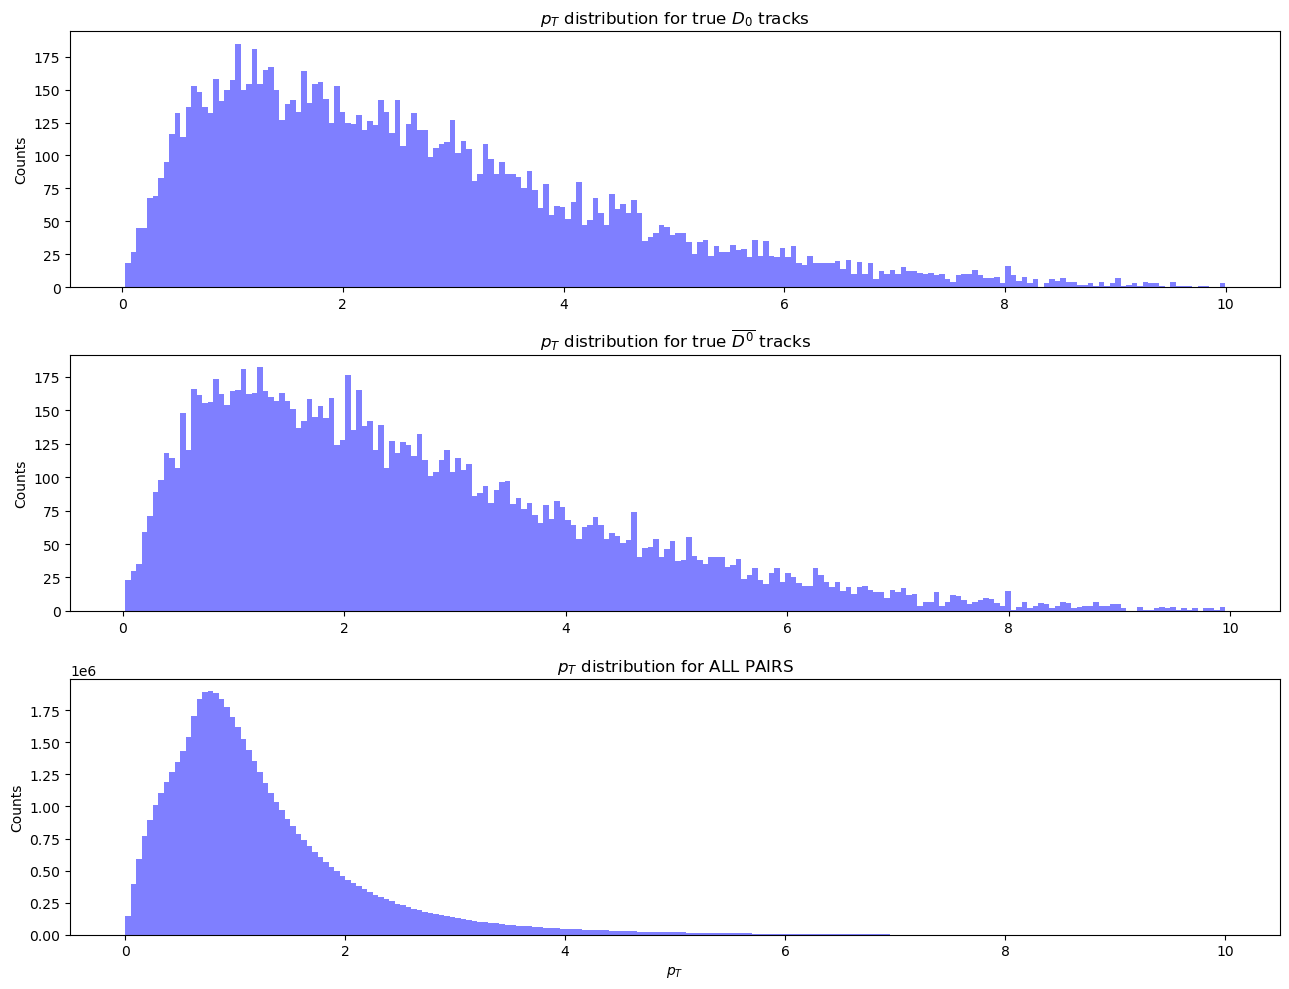

In [6]:
N_BINS = 200
fig, axs = plt.subplots(3, 1, figsize=(13, 10))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for ALL PAIRS")

plt.tight_layout()
plt.show()
del data

The $p_T$ windows like $[2-4]$, $[3-6]$ or $[3-8]$ could be useful to find the signal.

## DEFINING $p_t$ WINDOWS
We want now to create the masks for the various $p_t$ slices, in order to better see the signal for each $p_t$ interval, for example: 0-1.5,1.5-3,3-8,8-16.  
Watch out: now $p_t$ is the transverse momentum of the mother particle, not of the single track!

In [7]:
multiple_masks_pt = [ 
    final_results["pt"].between(0, 1), 
    final_results["pt"].between(1, 3),
    final_results["pt"].between(3, 5),
    final_results["pt"].between(5, 16),
    final_results["pt"].between(5, 8),
    final_results["pt"].between(8, 16)
]

pt_windows = [ "0-1", "1-3", "3-5", "5-16", "5-8", "8-16" ]

In [8]:
# let's count signal and background for each pT window
signal_tot_per_pt = []
num_bg_pairs_per_pt = []

for mask_pt in multiple_masks_pt:

    # count signal for each pT window
    signal_tot_i = len(final_results.loc[mask_signal & mask_pt, "truth"])
    signal_tot_per_pt.append(signal_tot_i)

    # count background for each pT window
    bg_tot = len(final_results.loc[mask_background & mask_pt, "truth"])
    num_bg_pairs_per_pt.append(bg_tot)

In [9]:
# debug:
print("Signal in each bin:")
for i, signal in enumerate(signal_tot_per_pt):
    print(f"  Bin {pt_windows[i]}: {signal}")

print("\nBackground in each bin:")
for i, background in enumerate(num_bg_pairs_per_pt):
    print(f"  Bin {pt_windows[i]}: {background:_}")

print("\nSignal-to-background ratio in each bin:")
for i, (signal, background) in enumerate(zip(signal_tot_per_pt, num_bg_pairs_per_pt)):
    if background != 0:
        ratio = signal / background
        print(f"  Bin {pt_windows[i]}: {ratio:.4f}")
    else:
        print(f"  Bin {i}: undefined (background = 0)")

Signal in each bin:
  Bin 0-1: 4306
  Bin 1-3: 11133
  Bin 3-5: 5667
  Bin 5-16: 2664
  Bin 5-8: 2376
  Bin 8-16: 288

Background in each bin:
  Bin 0-1: 26_206_888
  Bin 1-3: 23_811_325
  Bin 3-5: 2_224_569
  Bin 5-16: 342_049
  Bin 5-8: 333_075
  Bin 8-16: 8_974

Signal-to-background ratio in each bin:
  Bin 0-1: 0.0002
  Bin 1-3: 0.0005
  Bin 3-5: 0.0025
  Bin 5-16: 0.0078
  Bin 5-8: 0.0071
  Bin 8-16: 0.0321


## POYNTING ANGLE in $p_T$ slices

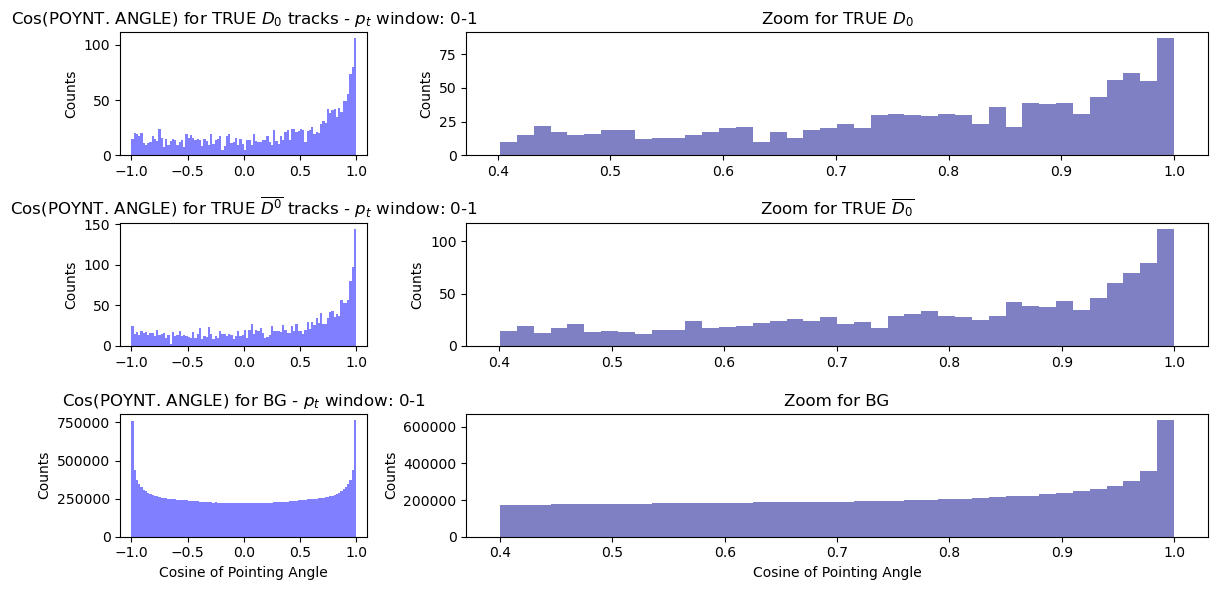

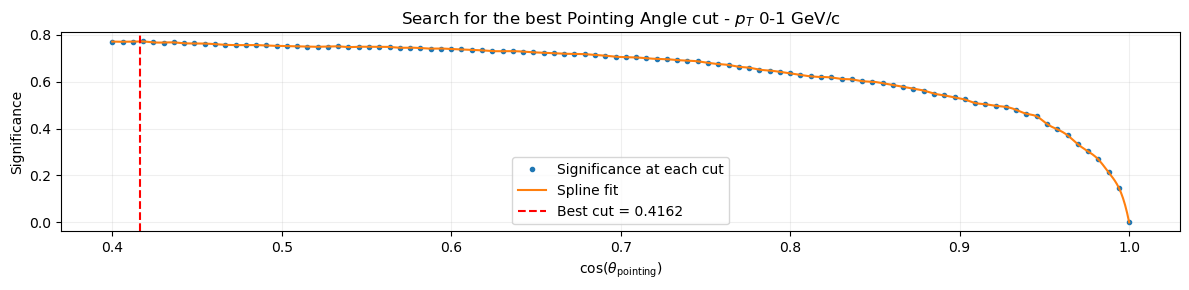

Best cut: cos(pointing) > 0.4162
With this cut we keep 52.09% of original signal in this slice
With this cut we keep 32.34% of background pairs in this slice


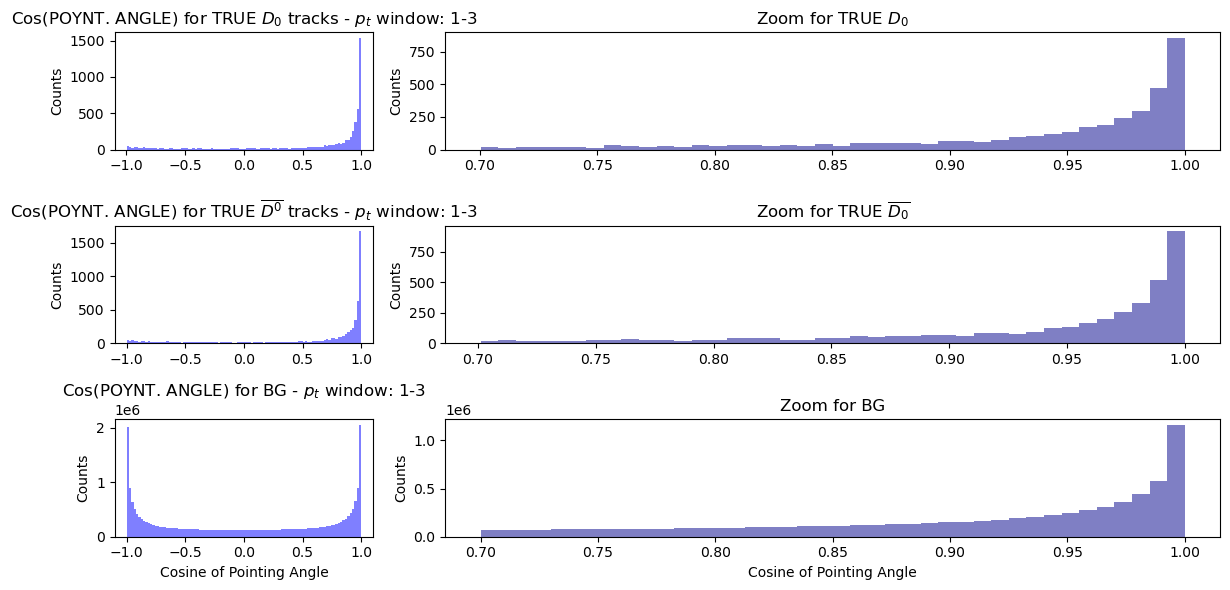

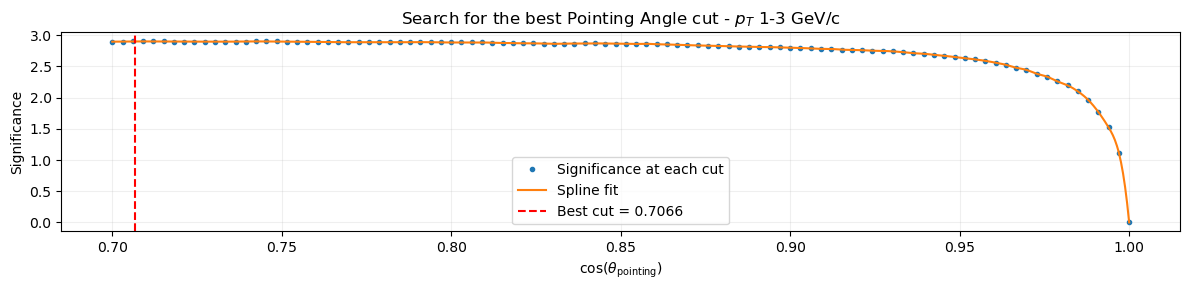

Best cut: cos(pointing) > 0.7066
With this cut we keep 69.33% of original signal in this slice
With this cut we keep 29.66% of background pairs in this slice


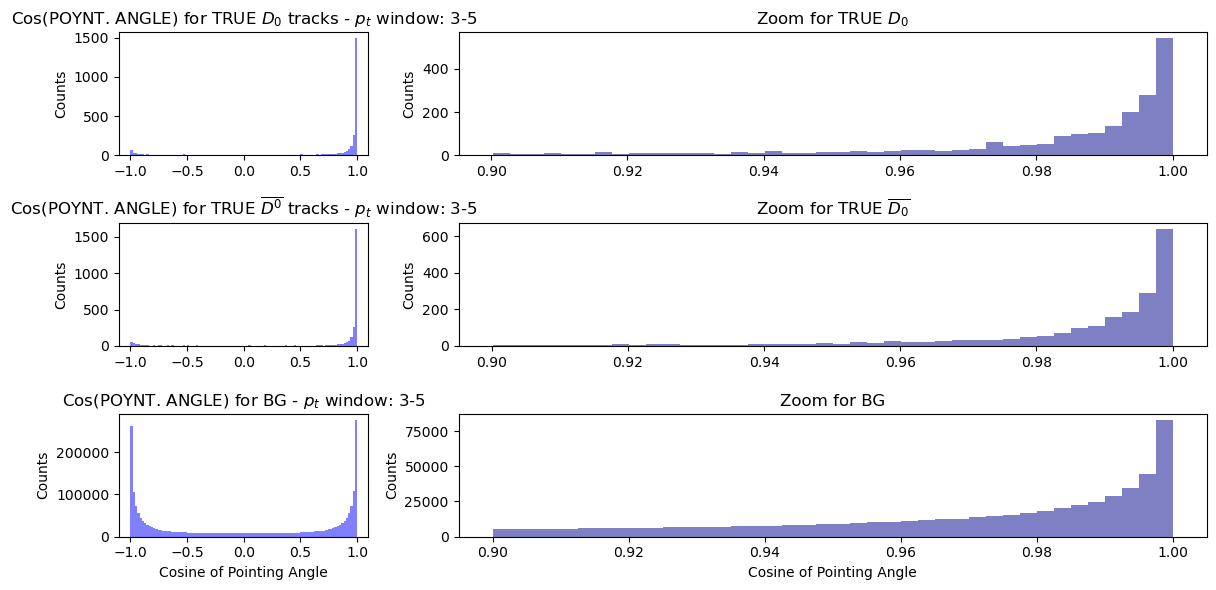

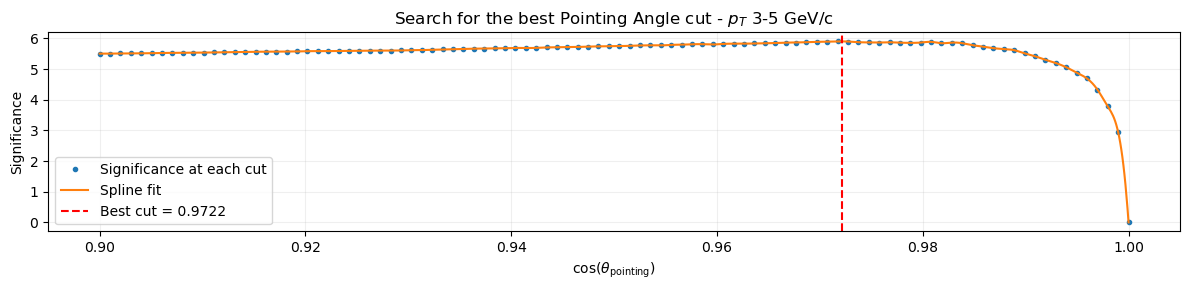

Best cut: cos(pointing) > 0.9722
With this cut we keep 59.71% of original signal in this slice
With this cut we keep 14.62% of background pairs in this slice


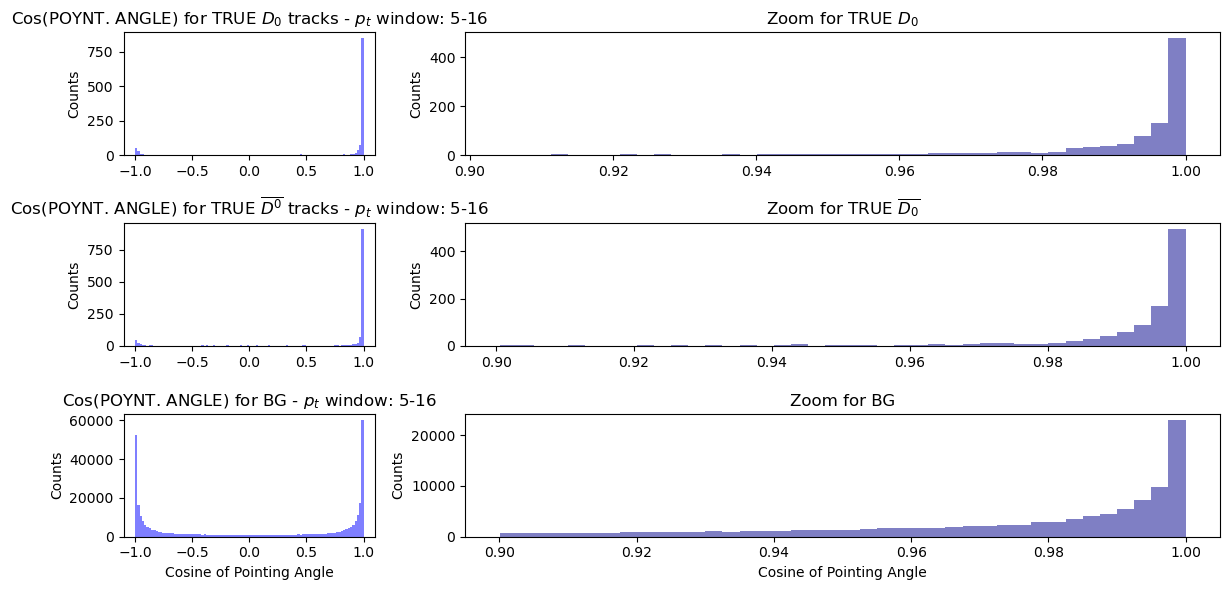

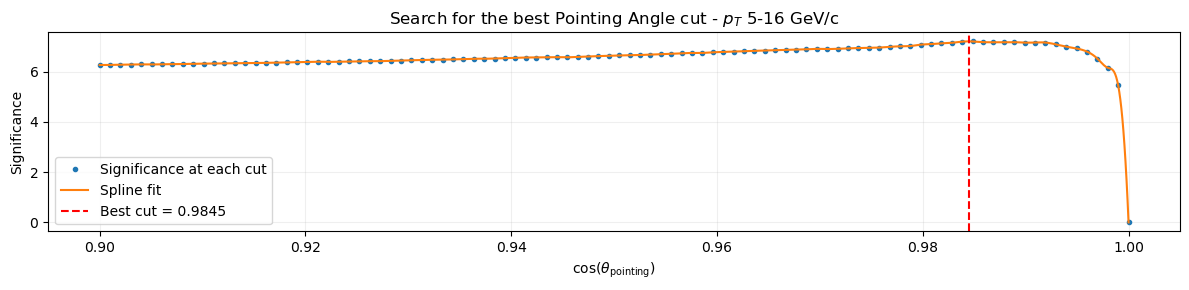

Best cut: cos(pointing) > 0.9845
With this cut we keep 64.19% of original signal in this slice
With this cut we keep 16.00% of background pairs in this slice


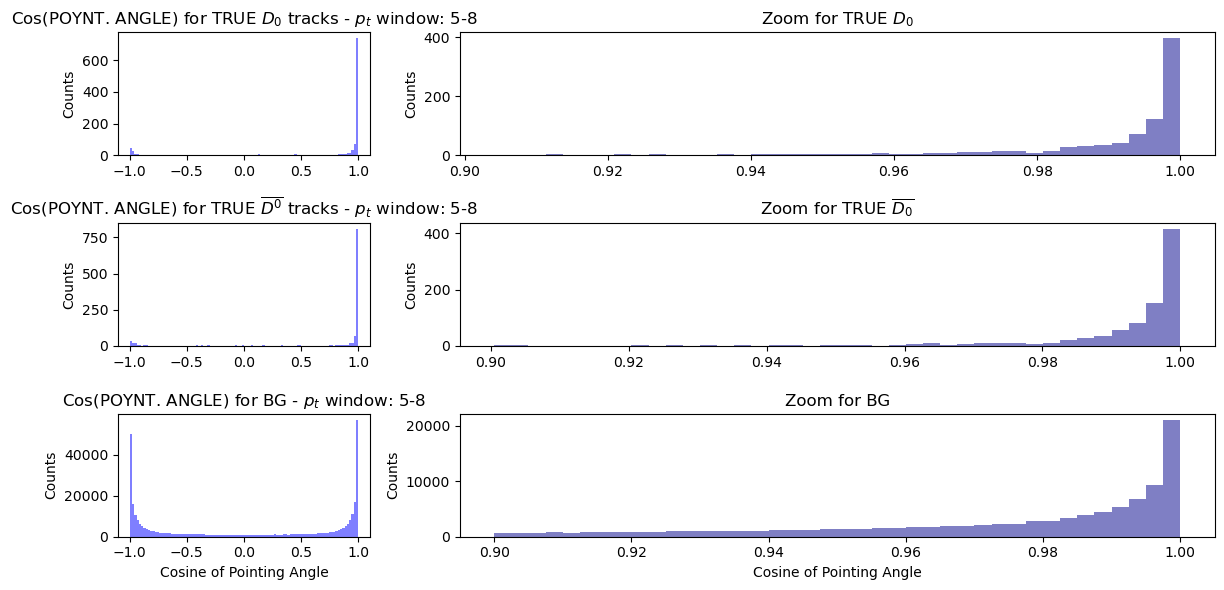

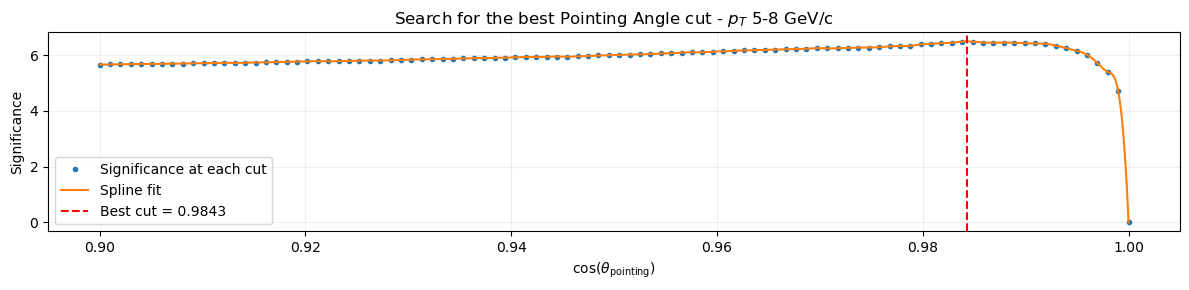

Best cut: cos(pointing) > 0.9843
With this cut we keep 63.22% of original signal in this slice
With this cut we keep 15.57% of background pairs in this slice


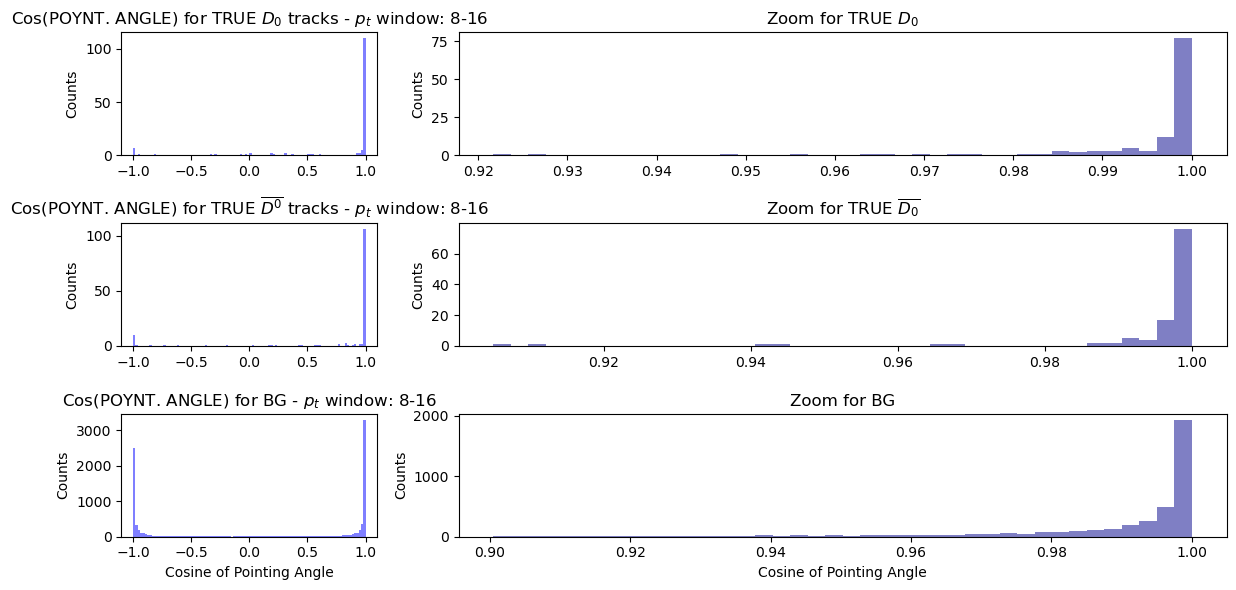

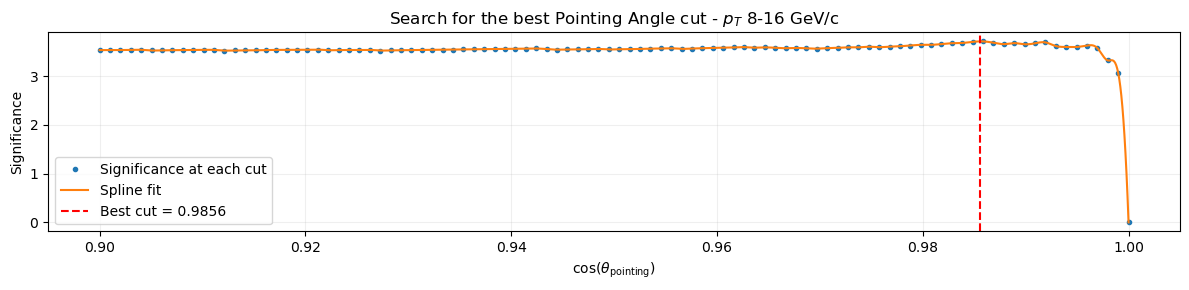

Best cut: cos(pointing) > 0.9856
With this cut we keep 74.31% of original signal in this slice
With this cut we keep 34.48% of background pairs in this slice


In [10]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )
    # meaningful cut for the zoom, depending on the pt slice we are in:
    match i:   # this command is like the usual "switch" in other languages
        case 0: cut = 0.4
        case 1: cut = 0.7
        case _: cut = 0.9
    
    # --- Plot cosine of poynting angle FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'cos_pointing'].values
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"Cos(POYNT. ANGLE) for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ data > cut ]
    axes["zoom_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot cosine of poynting angle FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'cos_pointing'].values
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"Cos(POYNT. ANGLE) for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ data > cut ]
    axes["zoom_anti_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title("Zoom for TRUE $\overline{D_0}$")
    
    # --- Plot cosine of poynting angle FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'cos_pointing'].values
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("Cosine of Pointing Angle")
    axes["total_all"].set_title(r"Cos(POYNT. ANGLE) for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ data > cut ]
    axes["zoom_all"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("Cosine of Pointing Angle")
    axes["zoom_all"].set_title("Zoom for BG")
    
    plt.tight_layout()
    plt.show()
    del data
    
    # --------------------- SEARCH FOR BEST CUT ----------------------------------------------
    # meaningful values for x axis, depending on the pt slice we are in:
    match i: 
        case 0 | 1: x_val = np.linspace(cut , 1, 100)     # case for i=0 or i=1
        case _: x_val = np.linspace( 0.9 , 1, 100)
    y_val =[]       # this will save the significance value for each cut
    
    signal_pointing = final_results.loc[ mask_pt & mask_signal, 'cos_pointing'].values
    background_pointing = final_results.loc[ mask_pt & mask_background, 'cos_pointing'].values
    
    for x in x_val:
        numerator = np.sum(signal_pointing > x)
        denominator = np.sum(background_pointing > x)
        total = numerator + denominator
        if total == 0:  y_val.append(0)   # significance is zero if no events survive
        else:           y_val.append(numerator / np.sqrt(total))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                  # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]     # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(12,3))
    ax.plot(x_val, y_val, 'o', markersize=3, label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel(r"$\cos(\theta_{\mathrm{pointing}})$")
    ax.set_ylabel('Significance')
    ax.set_title(f'Search for the best Pointing Angle cut - $p_T$ {pt_windows[i]} GeV/c')
    ax.legend()
    plt.tight_layout()
    plt.grid(alpha=0.2)
    plt.savefig(f"images/search_poynting_pt{pt_windows[i]}.png")
    plt.show()

    # PRINT results:
    print(f"Best cut: cos(pointing) > {best_cut:.4f}")
    print(f"With this cut we keep {len( signal_pointing[ signal_pointing>best_cut ] )/signal_tot_per_pt[i]*100:.2f}% of original signal in this slice")
    print(f"With this cut we keep {len( background_pointing[ background_pointing>best_cut ] )/num_bg_pairs_per_pt[i]*100:.2f}% of background pairs in this slice")
    

## dcaXY PRODUCT in $p_T$ slices

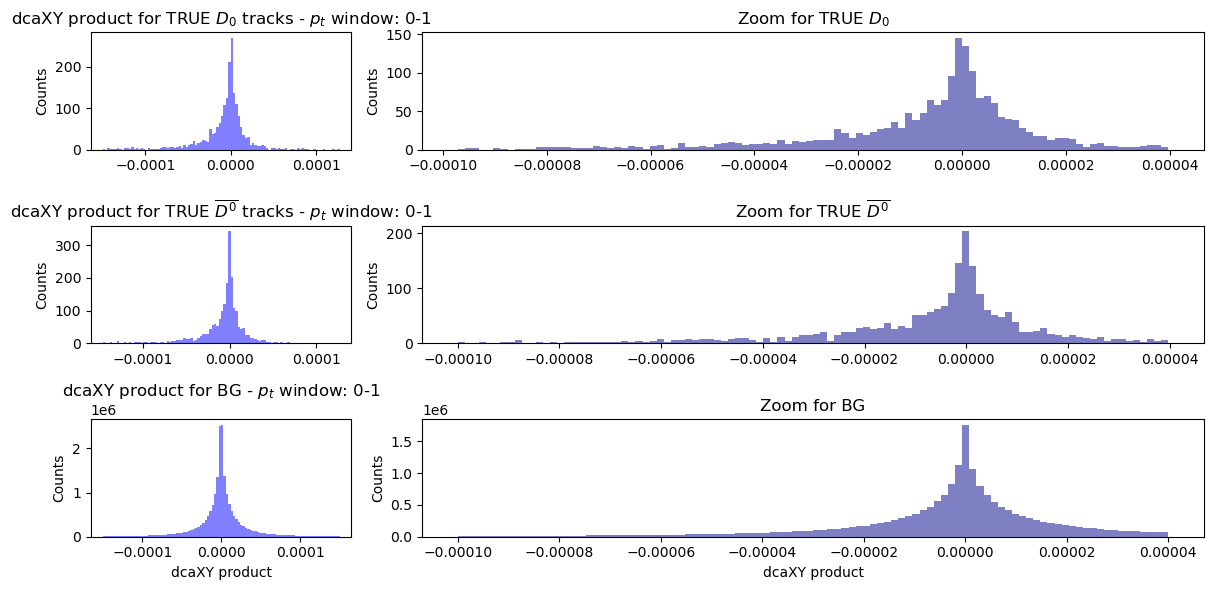

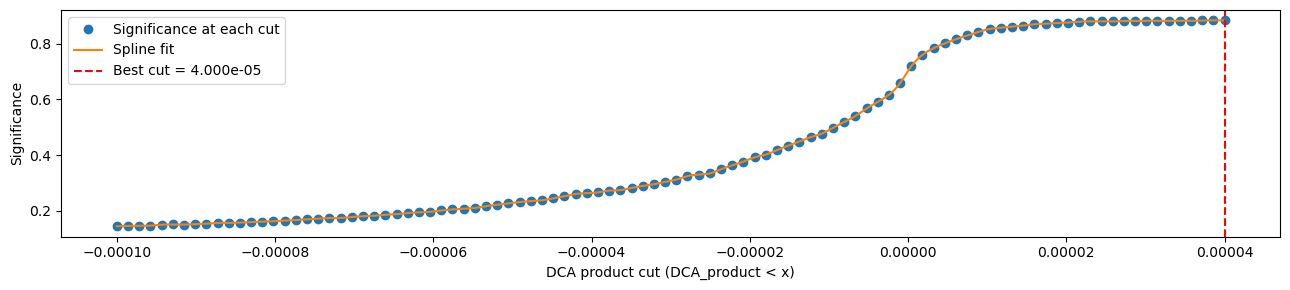

Best cut: (dcaXY product) < 4.000e-05
With this cut we keep 94.61% of original signal in this slice
With this cut we keep 81.04% of background pairs in this slice


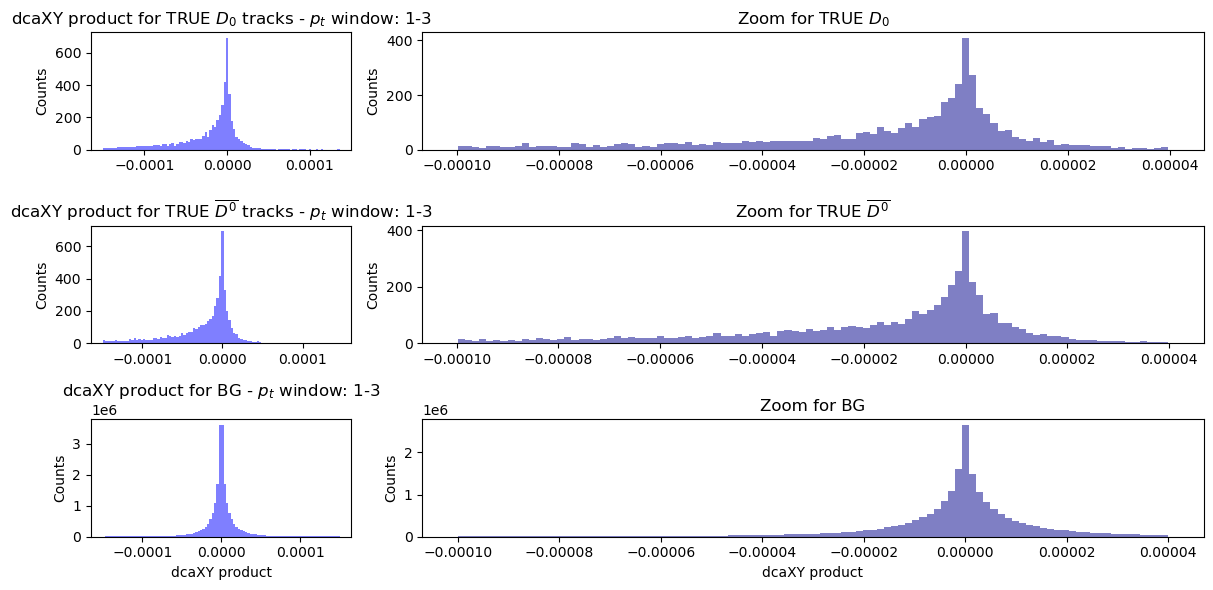

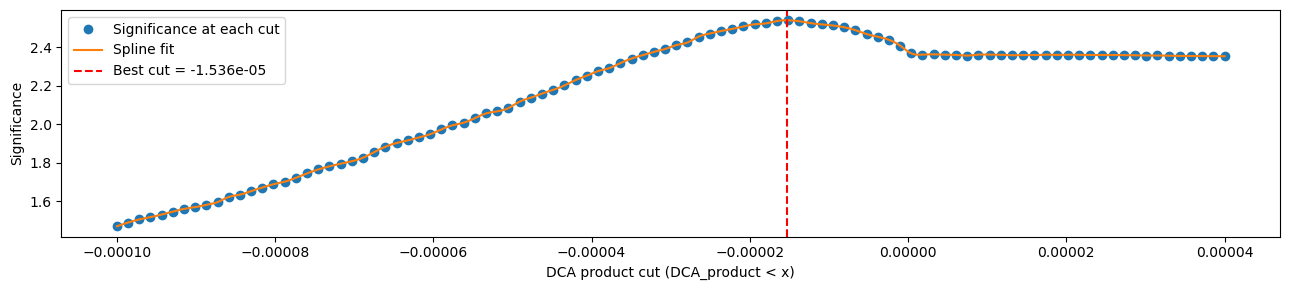

Best cut: (dcaXY product) < -1.536e-05
With this cut we keep 45.29% of original signal in this slice
With this cut we keep 16.48% of background pairs in this slice


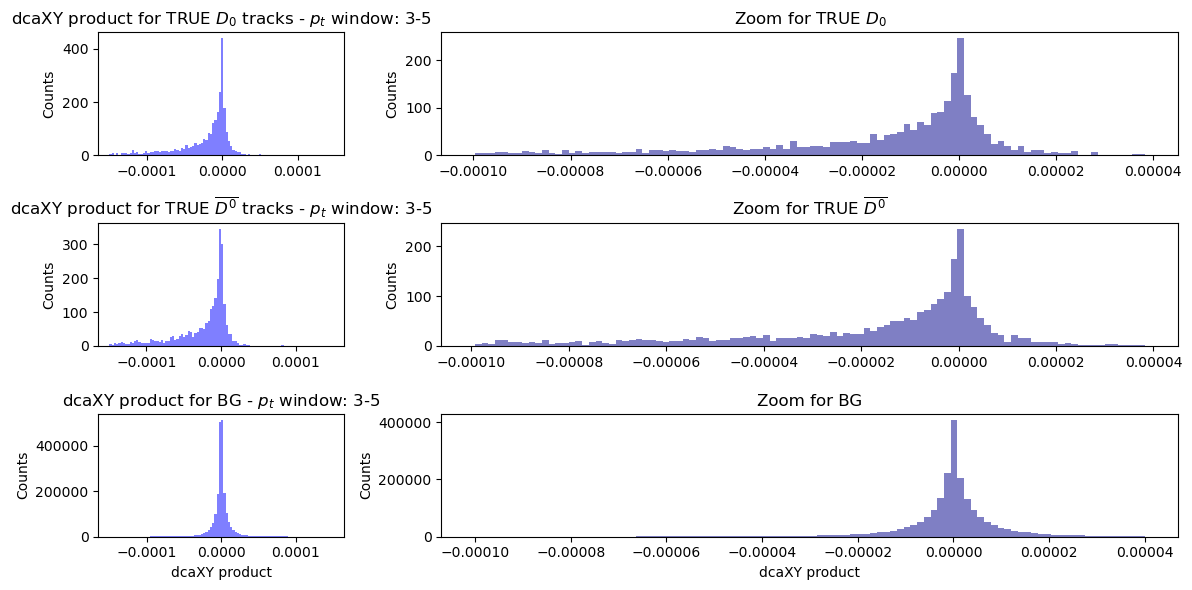

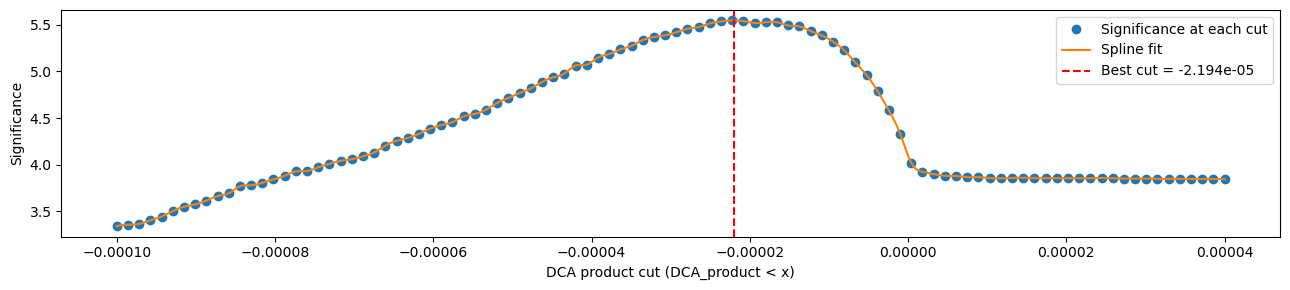

Best cut: (dcaXY product) < -2.194e-05
With this cut we keep 38.54% of original signal in this slice
With this cut we keep 6.85% of background pairs in this slice


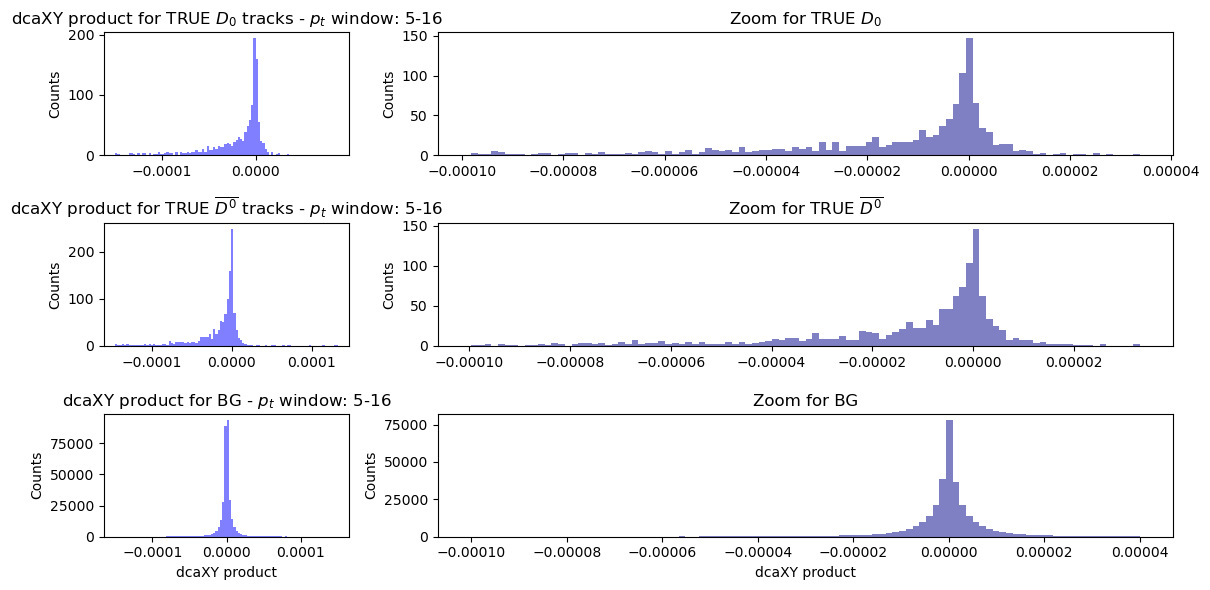

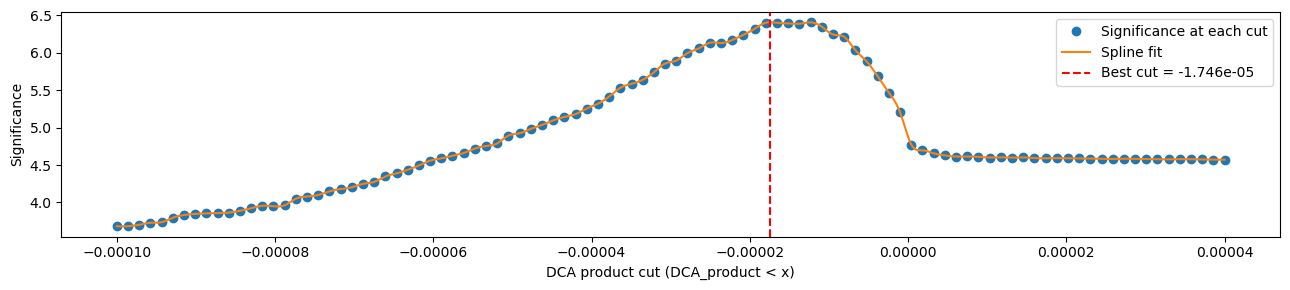

Best cut: (dcaXY product) < -1.746e-05
With this cut we keep 37.39% of original signal in this slice
With this cut we keep 6.79% of background pairs in this slice


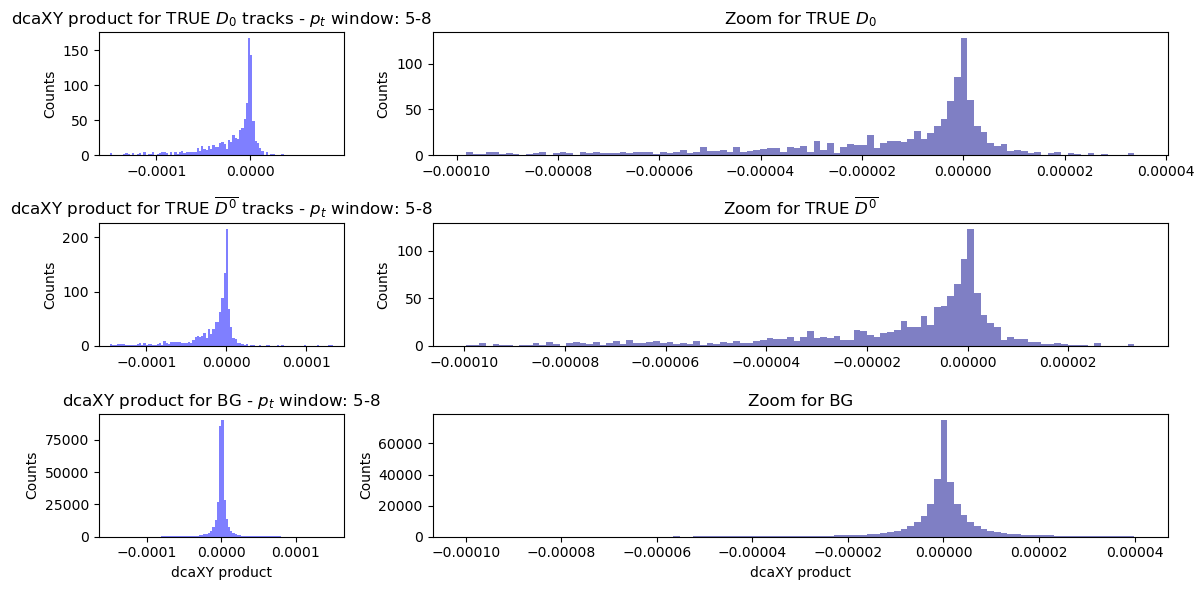

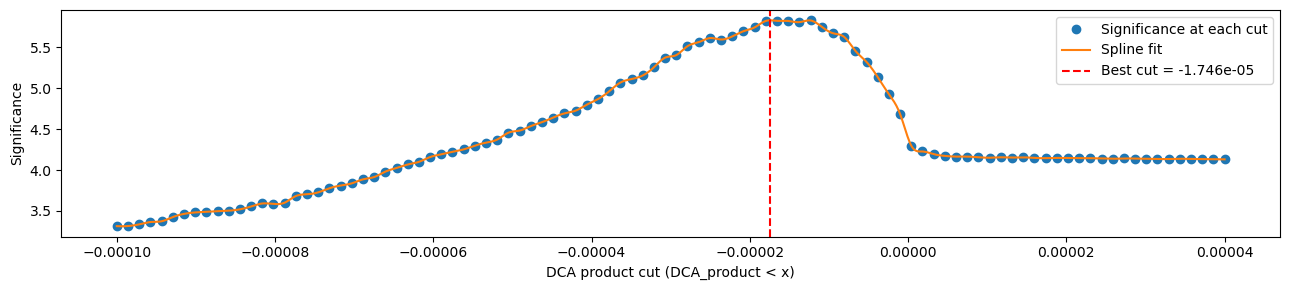

Best cut: (dcaXY product) < -1.746e-05
With this cut we keep 37.58% of original signal in this slice
With this cut we keep 6.81% of background pairs in this slice


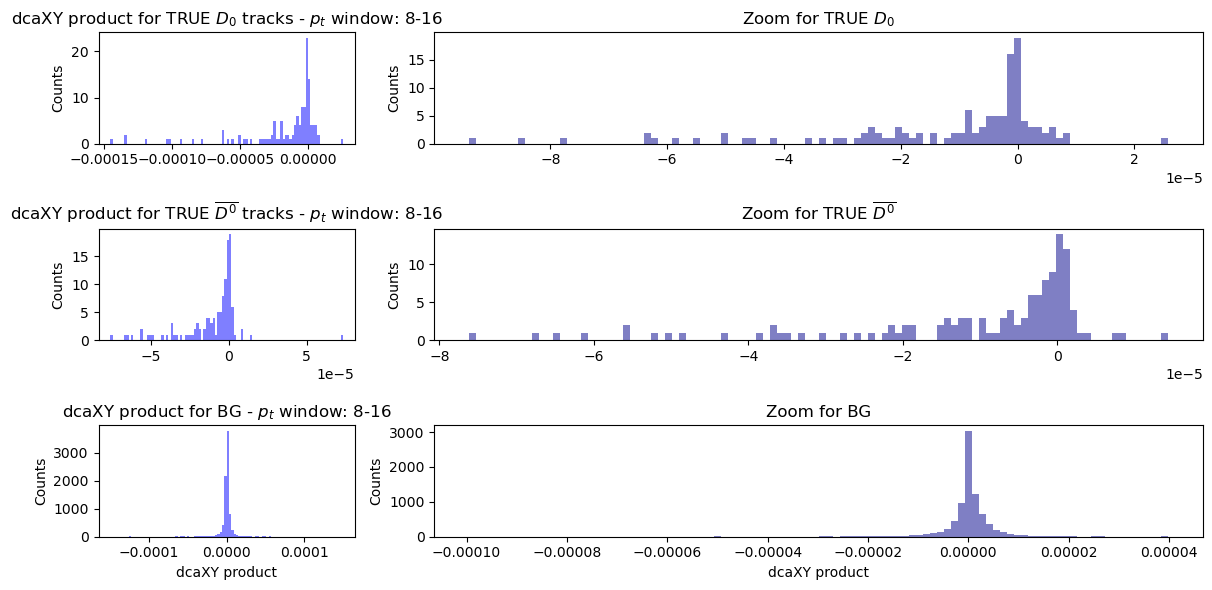

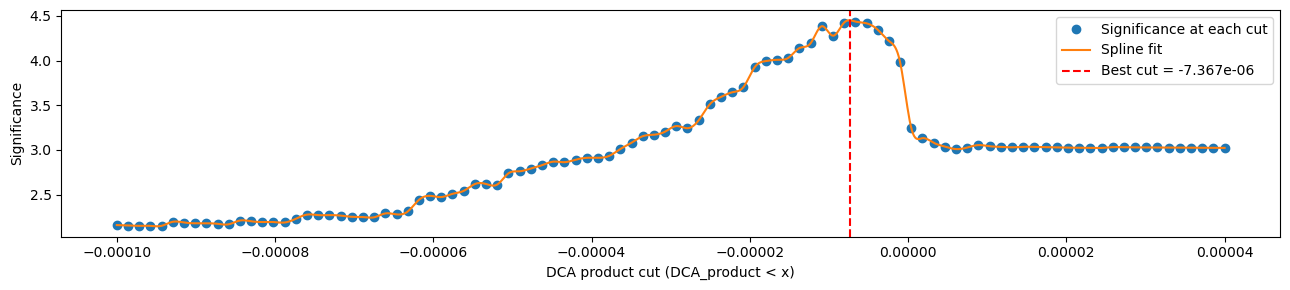

Best cut: (dcaXY product) < -7.367e-06
With this cut we keep 47.57% of original signal in this slice
With this cut we keep 9.19% of background pairs in this slice


In [11]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )
    # let's define the zoom cut:
    cut_inf = 0.0001
    cut_sup = 0.00004
    
    # --- Plot dcaXY product FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"dcaXY product for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot dcaXY product FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"dcaXY product for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))    
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_anti_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title(r"Zoom for TRUE $\overline{D^0}$")
    
    # --- Plot dcaXY product FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("dcaXY product")
    axes["total_all"].set_title(r"dcaXY product for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_all"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("dcaXY product")
    axes["zoom_all"].set_title("Zoom for BG")
    
    plt.tight_layout()
    plt.show()
    del data


    # --------------- SEARCH FOR BEST CUT IN DCA PRODUCT -------------------------------
    x_val = np.linspace( -0.0001, 0.00004, 100)
    y_val =[]                 # this will save the significance value for each cut
    
    signal_dca_prod = final_results.loc[ mask_pt & mask_signal, 'dcaXY_product'].values
    background_dca_prod = final_results.loc[ mask_pt & mask_background, 'dcaXY_product'].values
    
    for x in x_val:
        numerator = len( signal_dca_prod[ signal_dca_prod<x ] )
        denominator = len( background_dca_prod[ background_dca_prod<x ] )
        y_val.append(numerator / np.sqrt(numerator + denominator))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                 # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]    # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.3e}')
    ax.set_xlabel('DCA product cut (DCA_product < x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # PRINT results:
    print(f"Best cut: (dcaXY product) < {best_cut:.3e}")
    print(f"With this cut we keep {len( signal_dca_prod[ signal_dca_prod<best_cut ] )/signal_tot_per_pt[i]*100:.2f}% of original signal in this slice")
    print(f"With this cut we keep {len( background_dca_prod[ background_dca_prod<best_cut ] )/num_bg_pairs_per_pt[i]*100:.2f}% of background pairs in this slice")
  

## DECAY LENGTH in $p_T$ slices

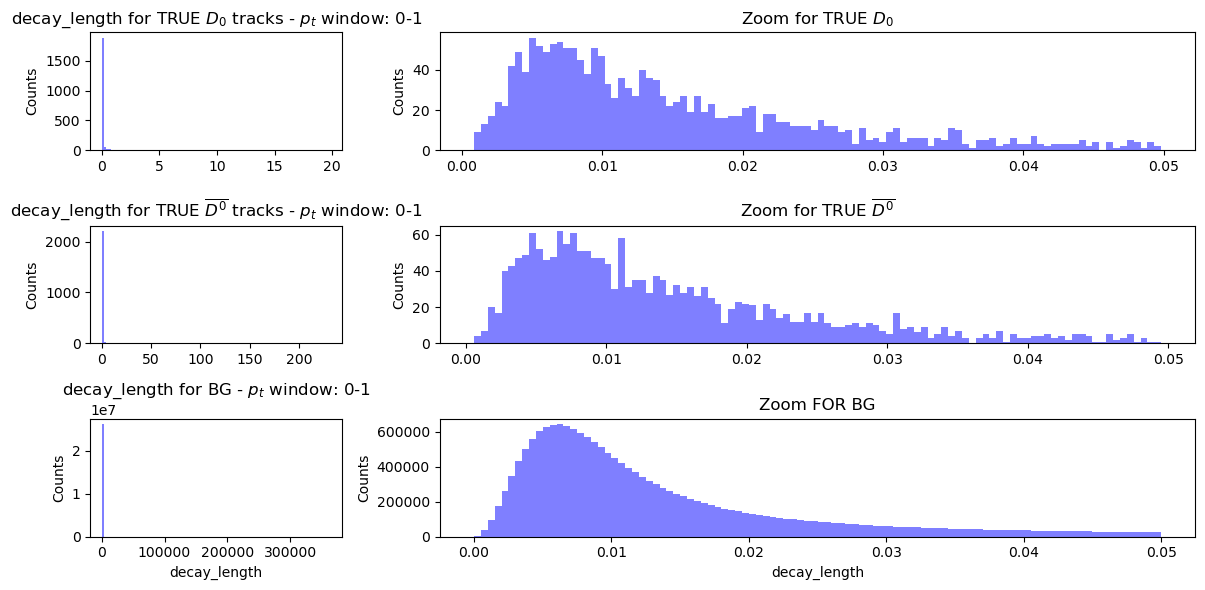

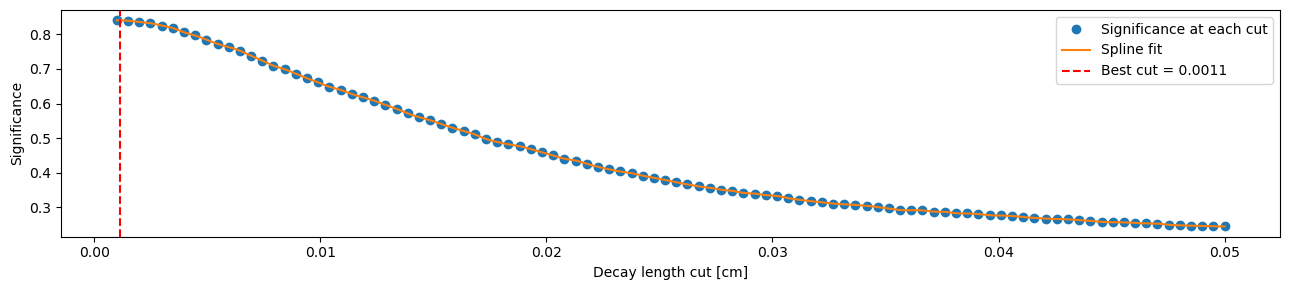

Best cut: (decay_length) > 0.0011
With this cut we keep 99.72% of the original signal in this slice
With this cut we keep 99.77% of the background pairs in this slice


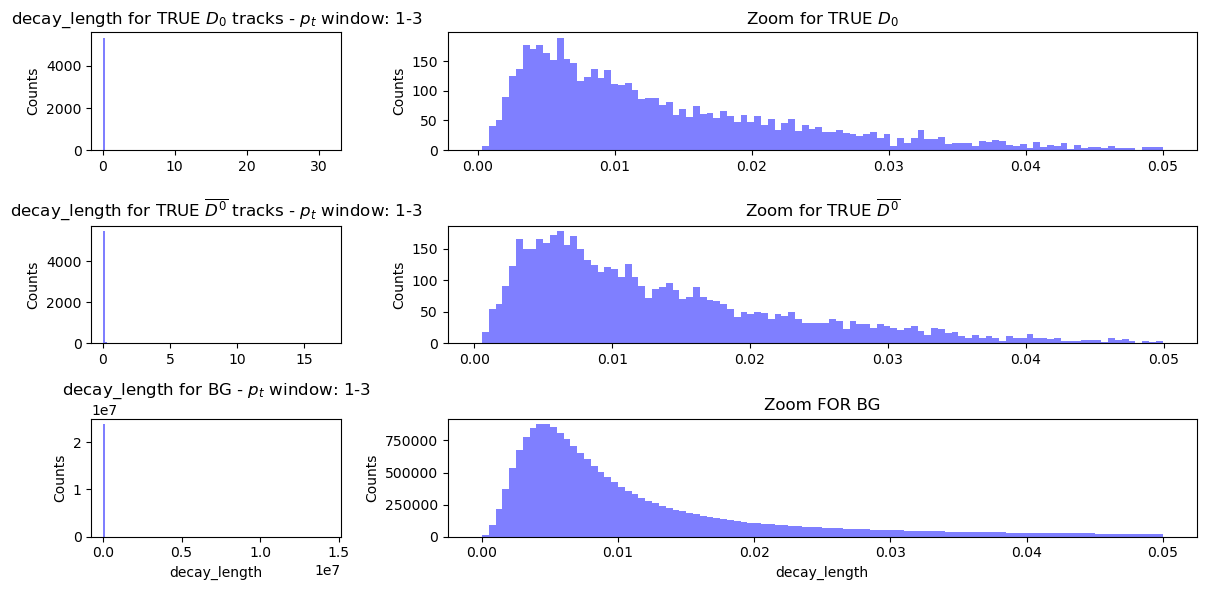

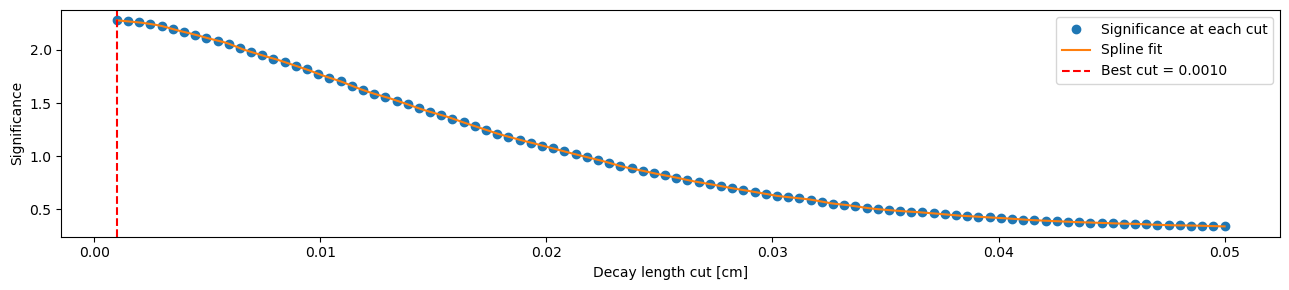

Best cut: (decay_length) > 0.0010
With this cut we keep 99.69% of the original signal in this slice
With this cut we keep 99.59% of the background pairs in this slice


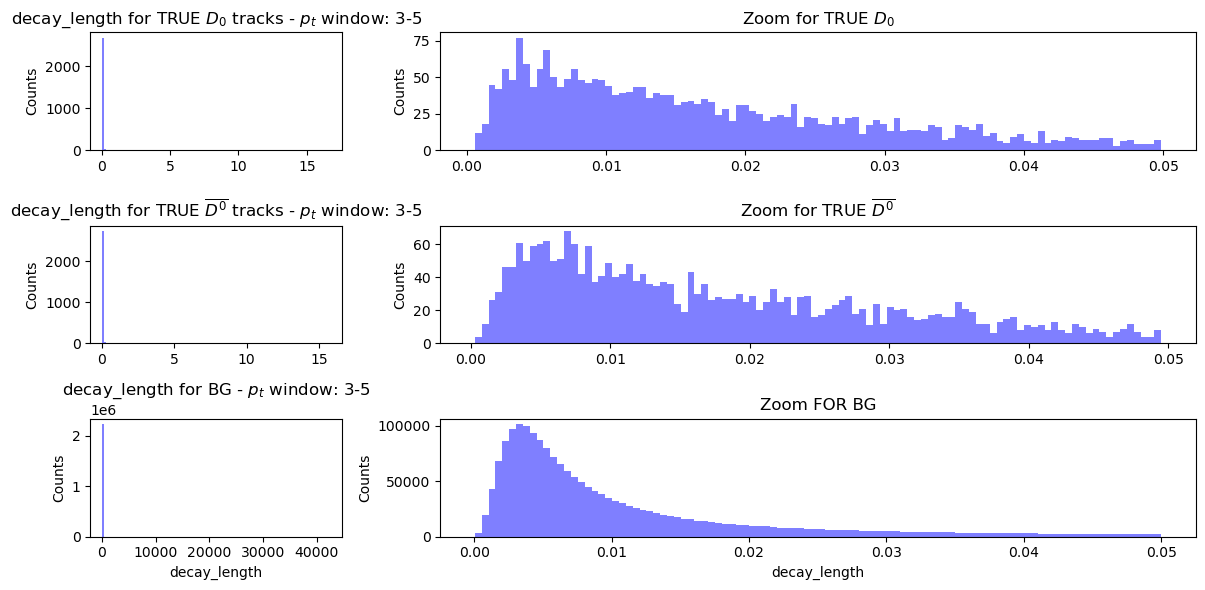

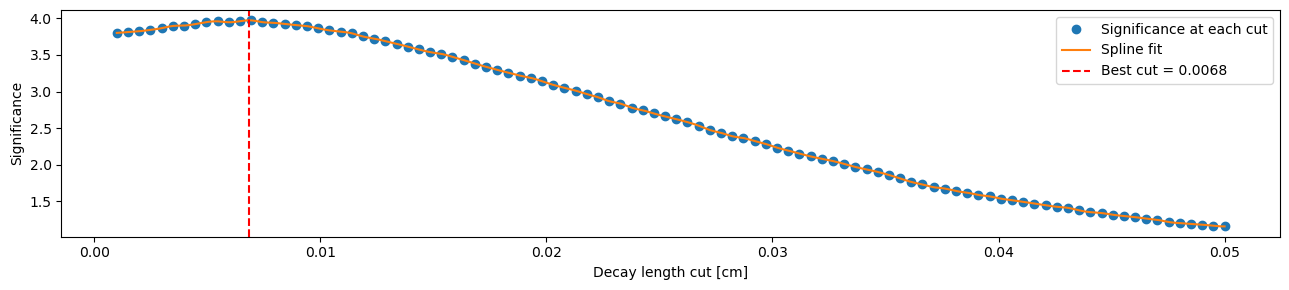

Best cut: (decay_length) > 0.0068
With this cut we keep 79.20% of the original signal in this slice
With this cut we keep 57.22% of the background pairs in this slice


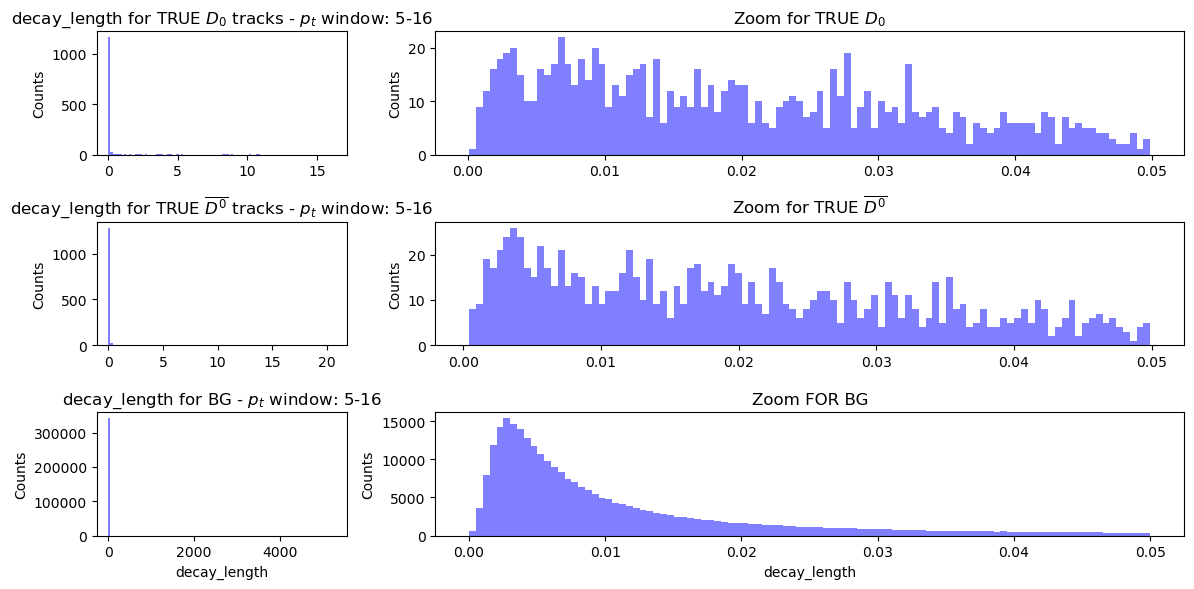

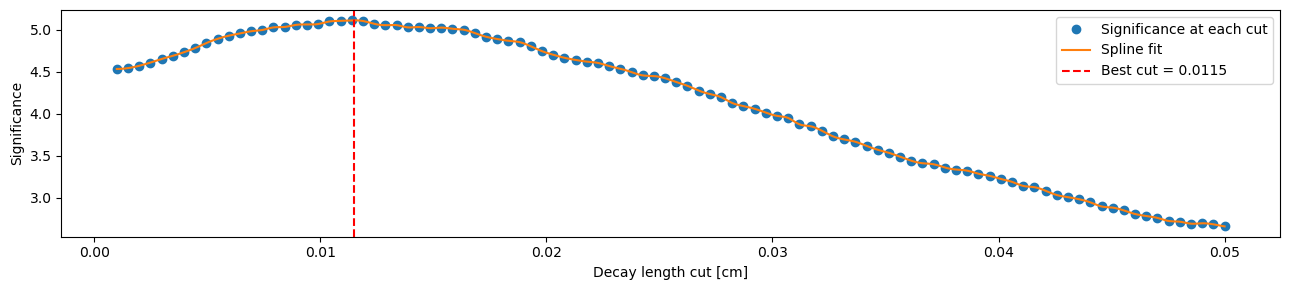

Best cut: (decay_length) > 0.0115
With this cut we keep 74.10% of the original signal in this slice
With this cut we keep 43.00% of the background pairs in this slice


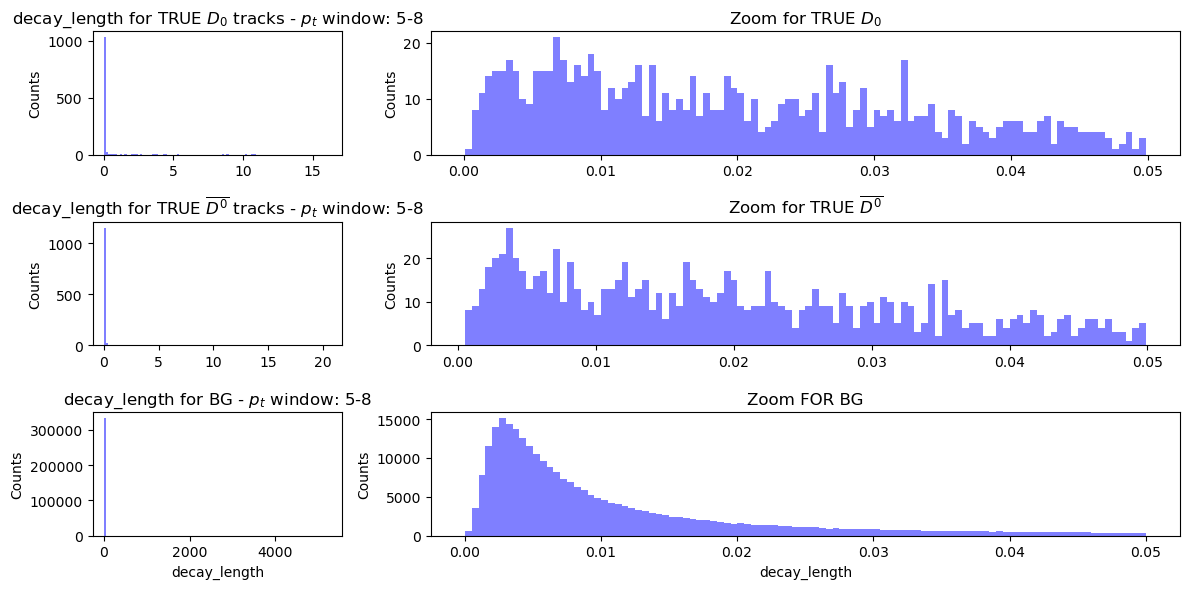

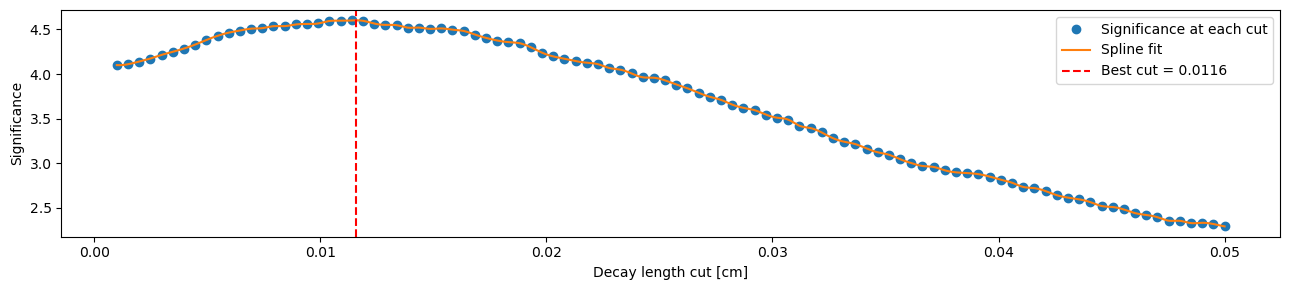

Best cut: (decay_length) > 0.0116
With this cut we keep 73.06% of the original signal in this slice
With this cut we keep 42.38% of the background pairs in this slice


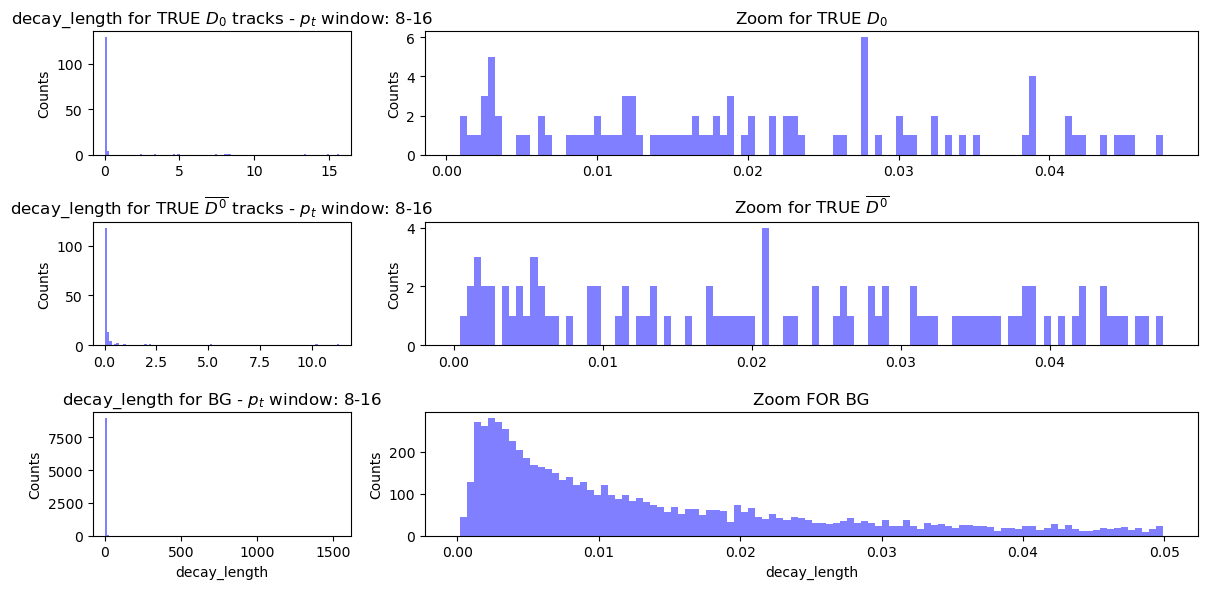

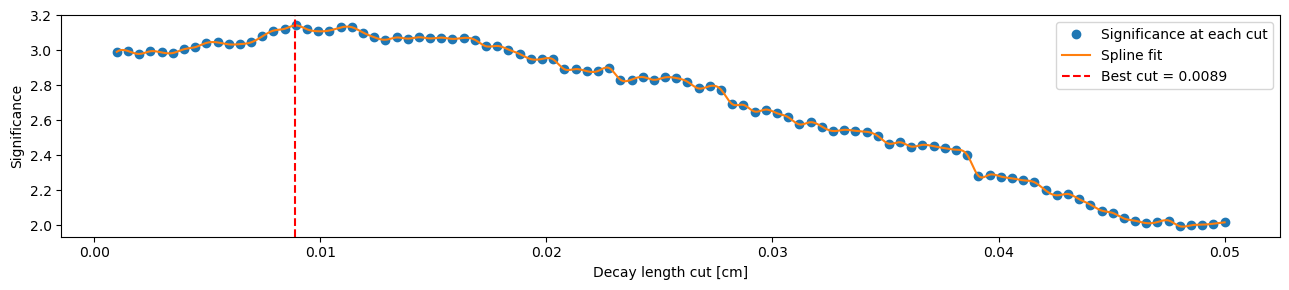

Best cut: (decay_length) > 0.0089
With this cut we keep 84.38% of the original signal in this slice
With this cut we keep 63.94% of the background pairs in this slice


In [12]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )

    # cut for the zoom part
    cut = 0.05
    
    # --- Plot decay length FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'decay_length'].values
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"decay_length for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ data < cut ]
    axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot decay length FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'decay_length'].values
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"decay_length for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ data < cut ]
    axes["zoom_anti_D0"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title(r"Zoom for TRUE $\overline{{D^0}}$")
    
    # --- Plot decay length FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'decay_length'].values
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("decay_length")
    axes["total_all"].set_title("decay_length for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ data < cut ]
    axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("decay_length")
    axes["zoom_all"].set_title("Zoom FOR BG")
    
    plt.tight_layout()
    plt.show()
    del data

    # ---------------------------- SEARCH FOR BEST CUTS FOR DECAY LENGTH ------------------------------------
    # --- RANGE OF CUTS ---
    x_val = np.linspace(0.001, 0.05, 100)
    y_val = []
    
    # --- DATA ---
    signal_dl = final_results.loc[ mask_pt & mask_signal, 'decay_length'].values
    background_dl = final_results.loc[ mask_pt & mask_background, 'decay_length'].values
    
    # --- SCAN ---
    for x in x_val:
        numerator = len( signal_dl[ signal_dl > x ] )
        denominator = len( background_dl[ background_dl > x ] )
        if numerator + denominator > 0:
            y_val.append(numerator / np.sqrt(numerator + denominator))
        else: y_val.append(0)
    
    # --- INTERPOLATION ---
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)
    best_cut = x_dense[np.argmax(y_dense)]
    
    # --- PLOT ---
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('Decay length cut [cm]')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # --- PRINT RESULTS ---
    print(f"Best cut: (decay_length) > {best_cut:.4f}")
    print(f"With this cut we keep {len(signal_dl[signal_dl > best_cut])/signal_tot_per_pt[i]*100:.2f}% of the original signal in this slice")
    print(f"With this cut we keep {len(background_dl[background_dl > best_cut])/num_bg_pairs_per_pt[i]*100:.2f}% of the background pairs in this slice")

### COMBINATION OF CUTS: POYNTING + DECAY LENGTH

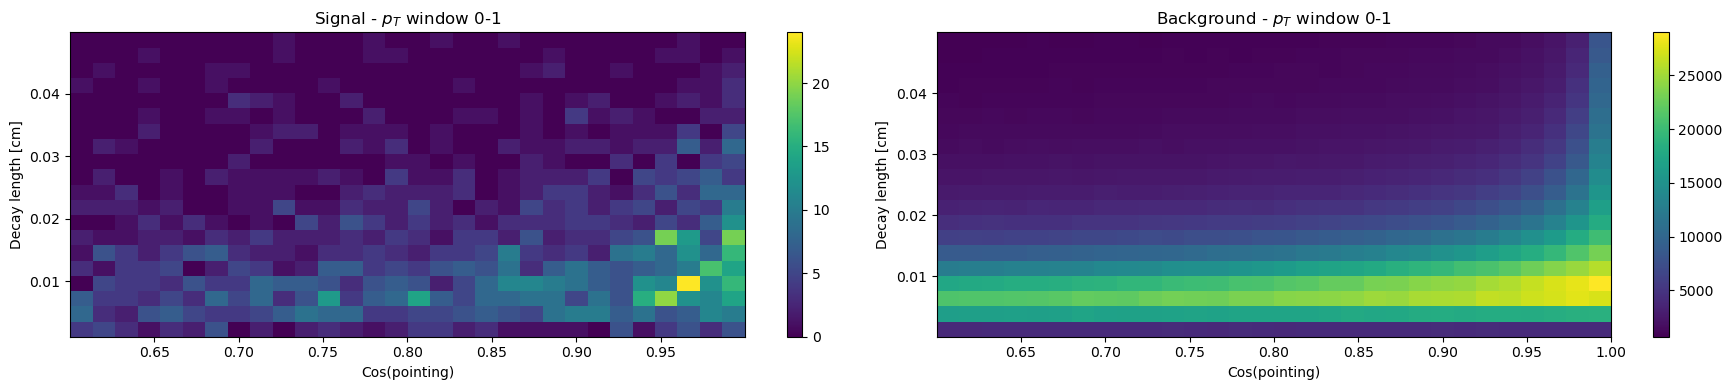

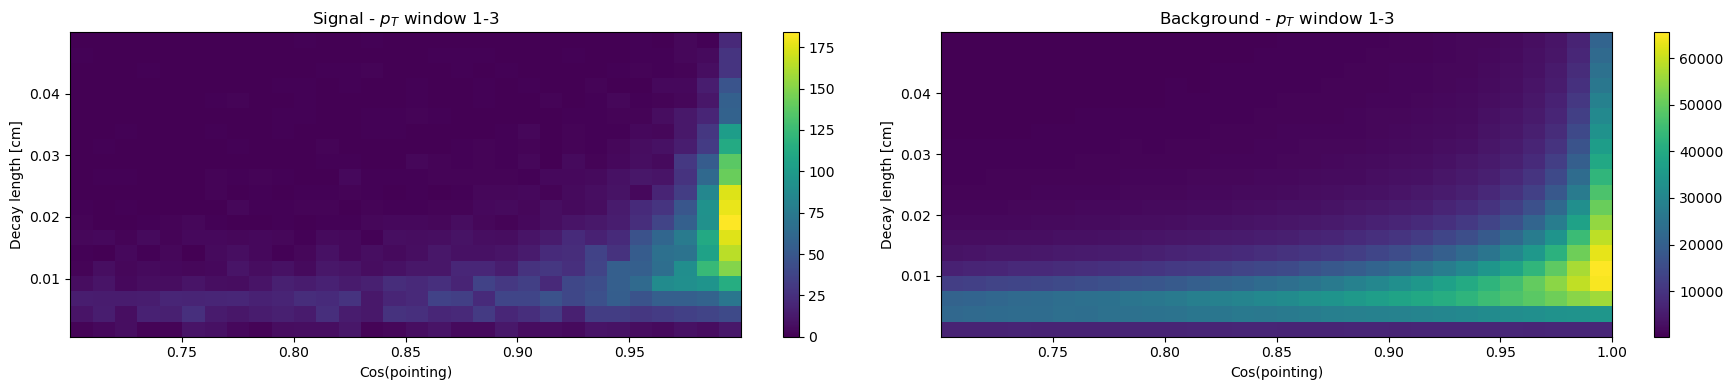

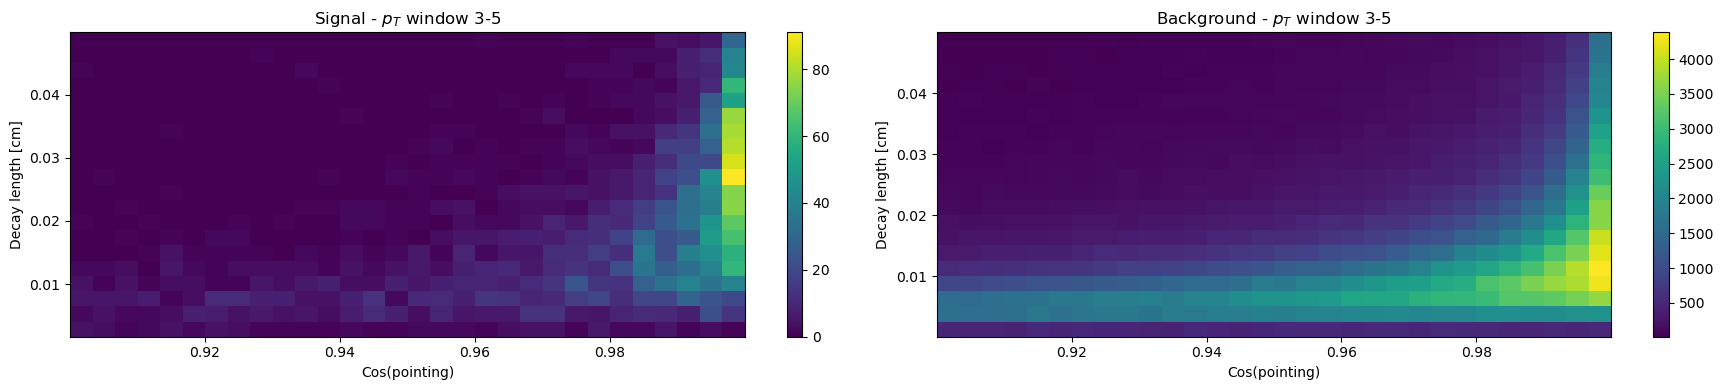

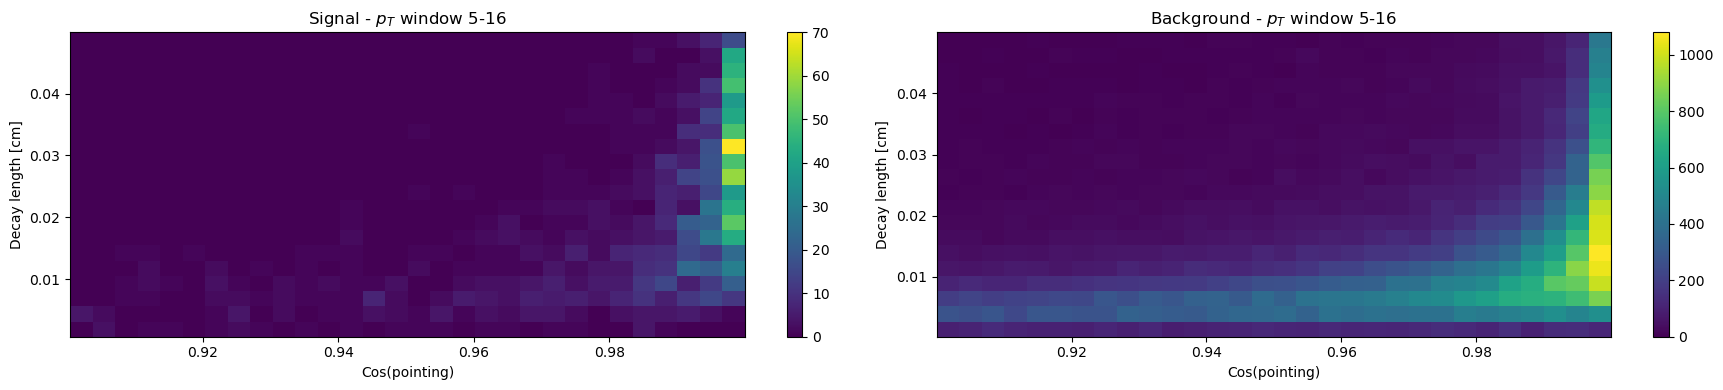

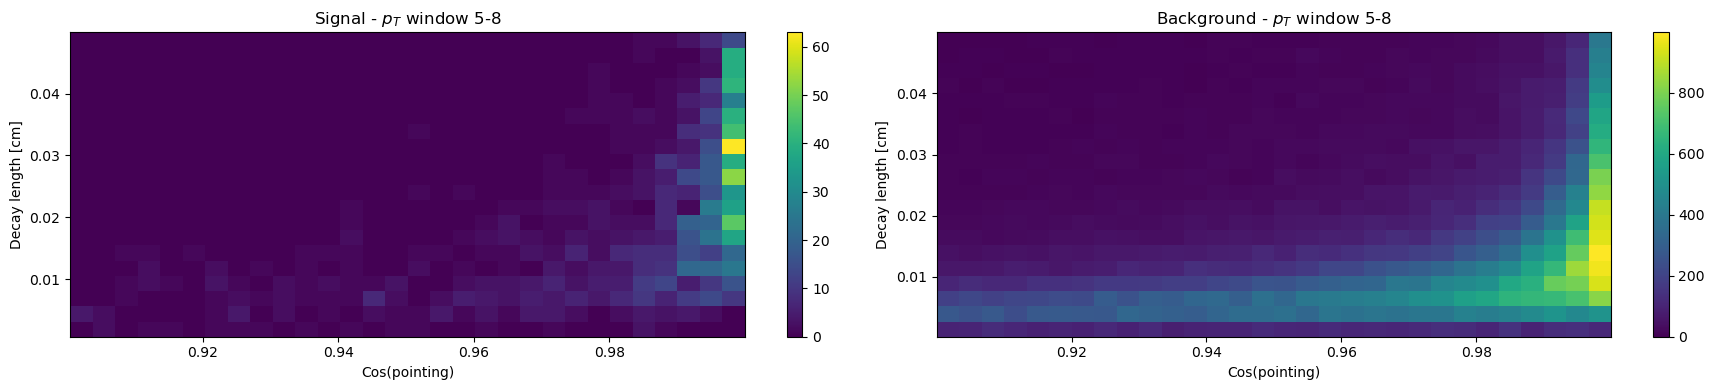

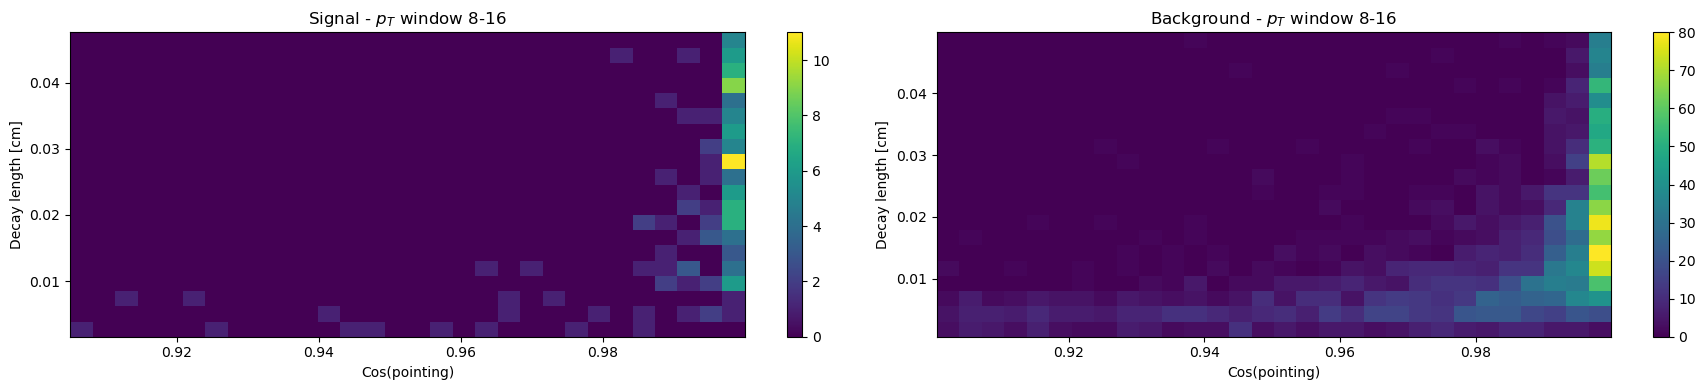

In [13]:
# choose the type of plot: "scatter", "hexbin", or "hist2d"
plot_type = "hist2d"

for i, mask_pt in enumerate(multiple_masks_pt):

    # define your two cases
    masks_cases = { "Signal" : mask_pt & mask_signal, "Background" : mask_pt & mask_background }
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    
    for ax, (label, mask) in zip(axes, masks_cases.items()):

        # CUTS TO FOCUS ON USEFUL AREAS:
        match i:   # this command is like the usual "switch" in other languages
            case 0: cut_poy = 0.6
            case 1: cut_poy = 0.7
            case _: cut_poy = 0.9
        cut_decay = 0.05
        # filter rows jointly to keep associated the two variables of a same row
        rows = final_results.loc[   mask &
                                    (final_results["cos_pointing"] > cut_poy) &
                                    (final_results["decay_length"] < cut_decay)
                                ]
        # now we extract x, y
        x = rows["cos_pointing"].values
        y = rows["decay_length"].values
        
        if plot_type == "scatter":
            ax.scatter(x, y, s=2, alpha=0.3)
        
        elif plot_type == "hexbin":
            hb = ax.hexbin(
                x, y, gridsize=50, cmap="viridis", mincnt=1
            )
            fig.colorbar(hb, ax=ax)
        
        elif plot_type == "hist2d":
            h = ax.hist2d(x, y, bins=[30,20], cmap="viridis")
            fig.colorbar(h[3], ax=ax)
        
        ax.set_title(f"{label} - $p_T$ window {pt_windows[i]}")
        ax.set_xlabel("Cos(pointing)")
        ax.set_ylabel("Decay length [cm]")

    plt.tight_layout()
    plt.show()


### APPLYING PAIR VARIABLES CUTS

In [14]:
# # let's define the cuts for each pt window:
# cuts_config = [
#     # pt ∈ [0, 1.5]
#     dict(
#         cos_pointing = 0.5636
#         # no dca product cut here
#         # no decay_length cut here
#     ),
    
#     # pt ∈ [1.5, 3]
#     dict(
#         cos_pointing = 0.7934,
#         dcaXY_product = -2.068e-05
#         # no decay_length cut here
#     ),
    
#     # pt ∈ [3, 16]
#     dict(
#         cos_pointing = 0.9835,
#         dcaXY_product = -1.746e-05,
#         decay_length = 0.0069
#     )
# ]

In [15]:
# let's define the cuts for each pt window:
cuts_config = [
    # pt ∈ [0, 1]
    dict(
        cos_pointing = 0.4162
        # no dca product cut here
        # no decay_length cut here 
    ),
    
    # pt ∈ [1, 3]
    dict(
        cos_pointing = 0.7066,
        dcaXY_product = -1.536e-05
        # no decay_length cut here
    ),
    
    # pt ∈ [3, 5]
    dict(
        cos_pointing = 0.9722,
        dcaXY_product = -2.194e-05,
        decay_length = 0.0068
    ),

    # pt ∈ [5, 16]
    dict(
        cos_pointing = 0.9845,
        dcaXY_product = -1.746e-05,
        decay_length = 0.0115
    ),

    # pt ∈ [5, 8]
    dict(
        cos_pointing = 0.9843,
        dcaXY_product = -1.746e-05,
        decay_length = 0.0116
    ),

    # pt ∈ [8, 16]
    dict(
        cos_pointing = 0.9856,
        dcaXY_product = -0.737e-05,
        decay_length = 0.0089
    ),
]

In [16]:
# build pt-dependent cuts
cuts_per_pt = []

for pt_mask, cfg in zip(multiple_masks_pt, cuts_config):

    cut = pt_mask.copy()

    if "cos_pointing" in cfg:
        cut &= final_results["cos_pointing"] > cfg["cos_pointing"]
    if "dcaXY_product" in cfg:
        cut &= final_results["dcaXY_product"] < cfg["dcaXY_product"]
    if "decay_length" in cfg:
        cut &= final_results["decay_length"] > cfg["decay_length"]

    cuts_per_pt.append(cut)

# let's make a big OR over cuts:
cuts = cuts_per_pt[0]
for cut_pt in cuts_per_pt[1:]: cuts = cuts | cut_pt

In [17]:
# final cutted dataframe
final_results = final_results[cuts]

In [18]:
print("======== STATISTICS FOR PAIR DATAFRAME AFTER PAIR TRACKS CUTS ========= \n")

print(f"Length of dataframe: {len(final_results):_} rows\n")

# MOTHER HYPOTHESIS
mask_d0_hyp         = (final_results["mother_hyp"] == "D0")
mask_anti_d0_hyp    = (final_results["mother_hyp"] == "Anti-D0")
mask_both_hyp       = (final_results["mother_hyp"] == "BothSignal")
d0_hyp_tot       =   mask_d0_hyp.sum()
anti_d0_hyp_tot  =   mask_anti_d0_hyp.sum()
both_hyp_tot     =   mask_both_hyp.sum()
print("MOTHER HYPOTHESIS COUNTS:")
print(f"Number of hypothetic D0:               {d0_hyp_tot:_}")
print(f"Number of hypothetic Anti-D0:          {anti_d0_hyp_tot:_}")
print(f"Number of double hypothesis particles: {both_hyp_tot:_}")
print(f"Total hypothetic signal:               {d0_hyp_tot + anti_d0_hyp_tot + 2*both_hyp_tot:_} \n")

# ---------- let's redefine the masks for the MC info on TRUE D0 and anti-D0 ------
# I count the D0 that are either true D0 in D0 hypotheses or true D0 in 'both' hypotheses
mask_true_d0_after = ( mask_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == 1 )
# I count the anti-D0 that are either true anti-D0 in anti-D0 hypotheses or true anti-D0 in 'both' hypotheses
mask_true_anti_d0_after = ( mask_anti_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == -1 )
mask_signal_after = ( (mask_true_d0_after) | (mask_true_anti_d0_after) )
mask_background_after = ( ~mask_signal_after )

d0_tot_after = np.sum( mask_true_d0_after )
anti_d0_tot_after = np.sum( mask_true_anti_d0_after )
signal_tot_after = d0_tot_after + anti_d0_tot_after
num_bg_pairs_after = np.sum( mask_background_after )
print("TRUE SIGNAL COUNTS:")
print("Number of D0:      ", d0_tot_after )
print("Number of anti-D0: ", anti_d0_tot_after )
print(f"Number of signal particles: ", signal_tot_after )
print(f"Number of background pairs: {num_bg_pairs_after:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot_after+anti_d0_tot_after)/len(final_results) * 100:.4f}%"  )

======== STATISTICS FOR PAIR DATAFRAME AFTER PAIR TRACKS CUTS ========= 

Length of dataframe: 9_845_217 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               1_444_870
Number of hypothetic Anti-D0:          1_482_598
Number of double hypothesis particles: 6_917_749
Total hypothetic signal:               16_762_966 

TRUE SIGNAL COUNTS:
Number of D0:       4614
Number of anti-D0:  5059
Number of signal particles:  9673
Number of background pairs: 9_835_544
Fraction of D0 and anti-D0 over total: 0.0983%


### $p_T$ distribution after cuts

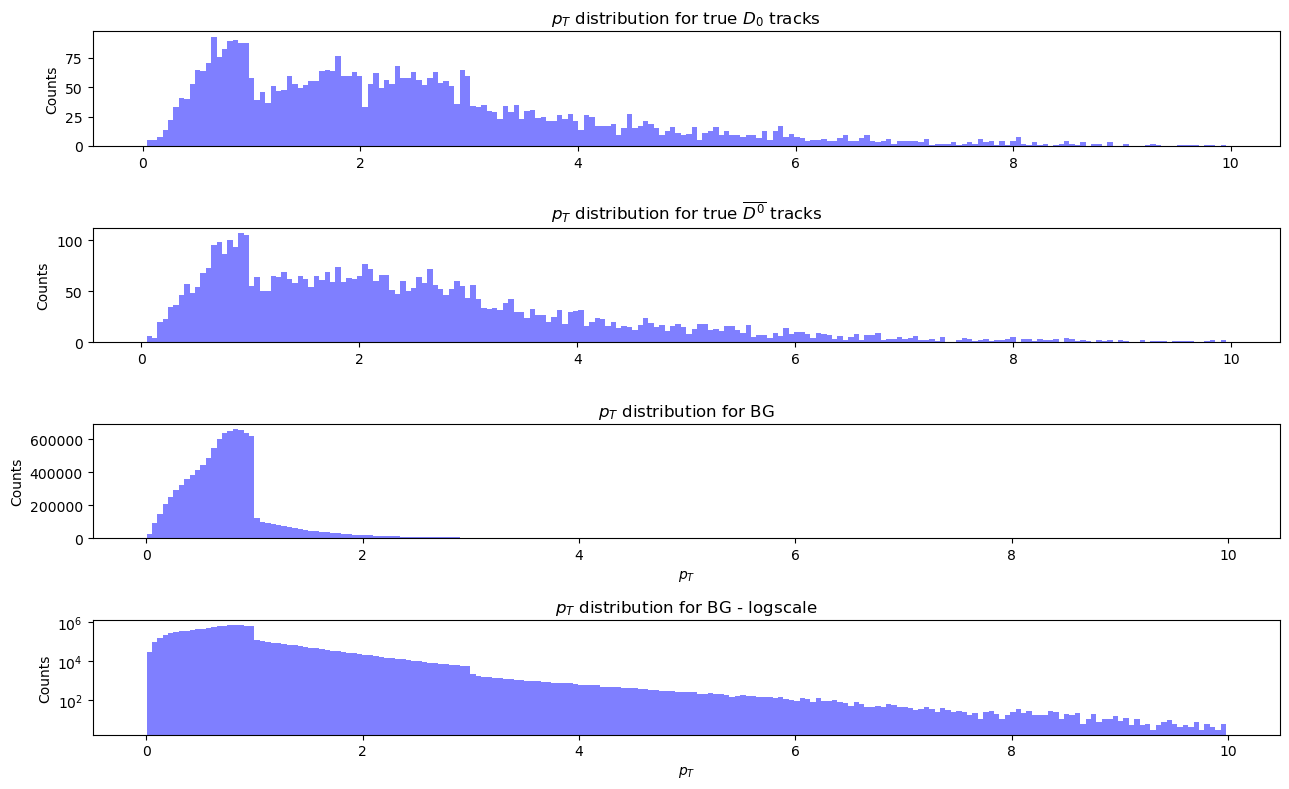

In [19]:
N_BINS = 200
fig, axs = plt.subplots(4, 1, figsize=(13, 8))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0_after, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0_after, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results.loc[mask_background_after, 'pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for BG")

# --- pT FOR ALL PAIRS - logscale ---
data = final_results.loc[mask_background_after, 'pt'].values
data = data[data < 10]
axs[3].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[3].set_xlabel("$p_T$")
axs[3].set_ylabel("Counts")
axs[3].set_title("$p_T$ distribution for BG - logscale")
axs[3].set_yscale("log")

plt.tight_layout()
plt.show()
del data

It's evident that we found good cuts in the $p_T$ windows $[1.5-3]$ and $[3-16]$, while in $[0-1.5]$ it was too hard.

In [20]:
print("Number of data lasted on each $p_T$ window:\n")

for i, mask_pt in enumerate(multiple_masks_pt):
    # count signal for each pT window
    signal_tot_i = np.sum( mask_signal_after & mask_pt )
    # count background for each pT window
    bg_tot = np.sum( mask_background_after & mask_pt )

    print(
        f"pT window {pt_windows[i]}: "
        f"Signal = {signal_tot_i}, "
        f"Background = {bg_tot:_}, "
        f"Total = {signal_tot_i + bg_tot:_}"
    )

Number of data lasted on each $p_T$ window:

pT window 0-1: Signal = 2243, Background = 8_476_341, Total = 8_478_584
pT window 1-3: Signal = 4631, Background = 1_324_218, Total = 1_328_849
pT window 3-5: Signal = 1912, Background = 29_149, Total = 31_061
pT window 5-16: Signal = 887, Background = 5_836, Total = 6_723
pT window 5-8: Signal = 767, Background = 5_322, Total = 6_089
pT window 8-16: Signal = 120, Background = 514, Total = 634


---

---

---

---

<center><span style="font-size:35px;"><b>CUTTED DATAFRAME</b></span></center>

### LET'S FOCUS ON THE $p_T$ window 3-16

In [173]:
df = final_results.loc[ final_results["pt"].between(8, 16) ]
i_window = 5

#### STATISTICS

In [174]:
print("======== STATISTICS FOR PAIR DATAFRAME of the best pT window ========= \n")

print(f"Length of dataframe: {len(df):_} rows\n")

# MOTHER HYPOTHESIS
mask_d0_hyp         = (df["mother_hyp"] == "D0")
mask_anti_d0_hyp    = (df["mother_hyp"] == "Anti-D0")
mask_both_hyp       = (df["mother_hyp"] == "BothSignal")
d0_hyp_tot       =   mask_d0_hyp.sum()
anti_d0_hyp_tot  =   mask_anti_d0_hyp.sum()
both_hyp_tot     =   mask_both_hyp.sum()
print("MOTHER HYPOTHESIS COUNTS:")
print(f"Number of hypothetic D0:               {d0_hyp_tot:_}")
print(f"Number of hypothetic Anti-D0:          {anti_d0_hyp_tot:_}")
print(f"Number of double hypothesis particles: {both_hyp_tot:_}")
print(f"Total hypothetic signal:               {d0_hyp_tot + anti_d0_hyp_tot + 2*both_hyp_tot:_} \n")

# ---------- let's redefine the masks for the MC info on TRUE D0 and anti-D0 ------
# I count the D0 that are either true D0 in D0 hypotheses or true D0 in 'both' hypotheses
mask_true_d0_cutted_pt = ( mask_d0_hyp | mask_both_hyp ) & ( df["truth"] == 1 )
# I count the anti-D0 that are either true anti-D0 in anti-D0 hypotheses or true anti-D0 in 'both' hypotheses
mask_true_anti_d0_cutted_pt = ( mask_anti_d0_hyp | mask_both_hyp ) & ( df["truth"] == -1 )
mask_signal_cutted_pt = ( (mask_true_d0_cutted_pt) | (mask_true_anti_d0_cutted_pt) )
mask_background_cutted_pt = ( ~mask_signal_cutted_pt )

d0_tot_cutted_pt = np.sum( mask_true_d0_cutted_pt )
anti_d0_tot_cutted_pt = np.sum( mask_true_anti_d0_cutted_pt )
signal_tot_cutted_pt = d0_tot_cutted_pt + anti_d0_tot_cutted_pt
num_bg_pairs_cutted_pt = np.sum( mask_background_cutted_pt )
print("TRUE SIGNAL COUNTS:")
print("Number of D0:      ", d0_tot_cutted_pt )
print("Number of anti-D0: ", anti_d0_tot_cutted_pt )
print(f"Number of signal particles: ", signal_tot_cutted_pt )
print(f"Number of background pairs: {num_bg_pairs_cutted_pt:_}")
print(f"Fraction of signal over total: {(d0_tot_cutted_pt+anti_d0_tot_cutted_pt)/len(df) * 100:.4f}%"  )

======== STATISTICS FOR PAIR DATAFRAME of the best pT window ========= 

Length of dataframe: 634 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               228
Number of hypothetic Anti-D0:          205
Number of double hypothesis particles: 201
Total hypothetic signal:               835 

TRUE SIGNAL COUNTS:
Number of D0:       60
Number of anti-D0:  60
Number of signal particles:  120
Number of background pairs: 514
Fraction of signal over total: 18.9274%


### REFLEX COMPONENT

In [175]:
# reflex component given by true D0 classified as anti-D0 hyp (and so we kept its anti-mass)
mask_reflex_from_anti_D0_hyp = mask_anti_d0_hyp & ( df["truth"] == 1 )
mass_reflex_from_anti_D0_hyp = df.loc[ mask_reflex_from_anti_D0_hyp, "anti_mass"].values

# reflex component given by true anti-D0 classified as D0 hyp (and so we kept its mass)
mask_reflex_from_D0_hyp = mask_d0_hyp & ( df["truth"] == -1 )
mass_reflex_from_D0_hyp =      df.loc[ mask_reflex_from_D0_hyp, "inv_mass"].values

# now the reflex component coming by the wrong mass in the 'both' hypothesis
mass_reflex_from_both_hyp = np.concatenate([ 
    df.loc[ mask_both_hyp & ( df["truth"] == 1 ), "anti_mass"].values,
    df.loc[ mask_both_hyp & ( df["truth"] == -1 ), "inv_mass"].values
])

reflex_data = np.concatenate([ 
    mass_reflex_from_anti_D0_hyp,
    mass_reflex_from_D0_hyp,
    mass_reflex_from_both_hyp
])

In [176]:
print("TRUE D0 CLASSIFICATION:")

n_d0_as_d0 = np.sum( (df["truth"] == 1) & mask_d0_hyp )
n_d0_as_anti = np.sum( (df["truth"] == 1) & mask_anti_d0_hyp )
n_d0_as_both = np.sum( (df["truth"] == 1) & mask_both_hyp )

print(f"Number of D0 classified as D0:       {n_d0_as_d0:_}")
print(f"Number of D0 classified as anti-D0:  {n_d0_as_anti:_}  (these are not kept in our true masks)")
print(f"Number of D0 classified as 'both':   {n_d0_as_both:_}\n")

print("TRUE ANTI-D0 CLASSIFICATION:")

n_anti_as_d0 = np.sum( (df["truth"] == -1) & mask_d0_hyp )
n_anti_as_anti = np.sum( (df["truth"] == -1) & mask_anti_d0_hyp )
n_anti_as_both = np.sum( (df["truth"] == -1) & mask_both_hyp )

print(f"Number of anti-D0 classified as D0:       {n_anti_as_d0:_} (these are not kept in our true masks)")
print(f"Number of anti-D0 classified as anti-D0:  {n_anti_as_anti:_}")
print(f"Number of anti-D0 classified as 'both':   {n_anti_as_both:_}\n")

print("REFLEX CLASSIFICATION:")

print(f"Number of reflex by wrong classified D0:        {len(mass_reflex_from_anti_D0_hyp)}" )
print(f"Number of reflex by wrong classified anti-D0:   {len(mass_reflex_from_D0_hyp)}")
print(f"Number of reflex by wrong classified in 'both': {len(mass_reflex_from_both_hyp)}")
print(f"Total reflex component: {len(mass_reflex_from_anti_D0_hyp) + len(mass_reflex_from_D0_hyp) + len(mass_reflex_from_both_hyp)} particles")

TRUE D0 CLASSIFICATION:
Number of D0 classified as D0:       47
Number of D0 classified as anti-D0:  2  (these are not kept in our true masks)
Number of D0 classified as 'both':   13

TRUE ANTI-D0 CLASSIFICATION:
Number of anti-D0 classified as D0:       2 (these are not kept in our true masks)
Number of anti-D0 classified as anti-D0:  48
Number of anti-D0 classified as 'both':   12

REFLEX CLASSIFICATION:
Number of reflex by wrong classified D0:        2
Number of reflex by wrong classified anti-D0:   2
Number of reflex by wrong classified in 'both': 25
Total reflex component: 29 particles


#### ALL DATA COMPONENT

In [177]:
# LET'S RETRIEVE THE MASS DATA:

# --- invariant mass selection based on mother hypothesis -----------------
mass_data_d0_hyp         = df.loc[mask_d0_hyp,     "inv_mass"].values
mass_data_anti_d0_hyp    = df.loc[mask_anti_d0_hyp, "anti_mass"].values

mass_data_both_hyp_inv   = df.loc[mask_both_hyp,   "inv_mass"].values
mass_data_both_hyp_anti  = df.loc[mask_both_hyp,   "anti_mass"].values

mass_data_hyp = np.concatenate([
    mass_data_d0_hyp,
    mass_data_anti_d0_hyp,
    mass_data_both_hyp_inv,
    mass_data_both_hyp_anti
])
print(f"We have {len(mass_data_hyp)} data particles")

# --- true signal mass data -------------------------------
mass_data_true_d0         = df.loc[ mask_true_d0_cutted_pt, "inv_mass"].values
mass_data_true_anti_d0    = df.loc[ mask_true_anti_d0_cutted_pt, "anti_mass"].values
mass_true_signal = np.concatenate([ mass_data_true_d0, mass_data_true_anti_d0 ])

print(f"We have {len(mass_true_signal)} signal particles")

We have 835 data particles
We have 120 signal particles


### BACKGROUND COMPONENT

In [178]:
# ----------------------- BACKGROUND MASS DATA -------------------------
mask_bg_d0_hyp        = mask_d0_hyp & (df["truth"] == 0)
mask_bg_anti_d0_hyp   = mask_anti_d0_hyp & (df["truth"] == 0)
mask_bg_both_hyp      = mask_both_hyp & (df["truth"] == 0)

mass_bg_d0_hyp       = df.loc[mask_bg_d0_hyp, "inv_mass"].values
mass_bg_anti_d0_hyp  = df.loc[mask_bg_anti_d0_hyp, "anti_mass"].values
mass_bg_both_hyp     = np.concatenate([
    df.loc[mask_bg_both_hyp, "inv_mass"].values,
    df.loc[mask_bg_both_hyp, "anti_mass"].values
])

mass_bg_all = np.concatenate([mass_bg_d0_hyp, mass_bg_anti_d0_hyp, mass_bg_both_hyp])

print(f"We have {len(mass_bg_all):_} bg particles (without reflex component)")

print(f"So in the end we have:\n")
print(f"{len(mass_true_signal)} singal part.  +  "
    f"{len(mass_reflex_from_anti_D0_hyp) + len(mass_reflex_from_D0_hyp) + len(mass_reflex_from_both_hyp)} reflex part.  +  "
    f"{len(mass_bg_all):_} bg particles = {len(mass_true_signal) +len(mass_reflex_from_anti_D0_hyp) + len(mass_reflex_from_D0_hyp) + len(mass_reflex_from_both_hyp) + len(mass_bg_all) :_} total particles. \n"
    f"that should be equal to the counted {len(mass_data_hyp):_} data particles\n"
)

# ------------------------------------------------------------------
# BACKGROUND D0 FROM OTHER DECAYS:
mask_fake_D0_hyp = mask_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
mask_fake_anti_D0_hyp = mask_anti_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]
mask_fake_D0_both_hyp = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
mask_fake_anti_D0_both_hyp = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]

mass_fake_d0_hyp       = df.loc[mask_fake_D0_hyp, "inv_mass"].values
mass_fake_anti_d0_hyp  = df.loc[mask_fake_anti_D0_hyp, "anti_mass"].values
mass_fake_both_hyp     = np.concatenate([
    df.loc[mask_fake_D0_both_hyp, "inv_mass"].values,
    df.loc[mask_fake_anti_D0_both_hyp, "anti_mass"].values
])

mass_fake_signal = np.concatenate([mass_fake_d0_hyp, mass_fake_anti_d0_hyp, mass_fake_both_hyp])
print(f"We have {len(mass_fake_signal)} bg particles that are D0 or anti-D0 from different decays (withoud reflex component)\n")

# ------------------------------------------------------------------
# BACKGROUND REFLEX D0 FROM OTHER DECAYS:
aaa = mask_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]
bbb = mask_anti_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
ccc = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
ddd = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]

eee       = df.loc[aaa, "inv_mass"].values
fff  = df.loc[bbb, "anti_mass"].values
ggg     = np.concatenate([
    df.loc[ccc, "anti_mass"].values,
    df.loc[ddd, "inv_mass"].values
])

mass_fake_reflex = np.concatenate([eee, fff, ggg])
print(f"We have {len(mass_fake_reflex)} bg particles that are D0 or anti-D0 from different decays (without reflex component)")



We have 686 bg particles (without reflex component)
So in the end we have:

120 singal part.  +  29 reflex part.  +  686 bg particles = 835 total particles. 
that should be equal to the counted 835 data particles

We have 81 bg particles that are D0 or anti-D0 from different decays (withoud reflex component)

We have 18 bg particles that are D0 or anti-D0 from different decays (without reflex component)


In [179]:
df.columns

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'mother_pdg_pos', 'truth', 'same_mother', 'mother_hyp'],
      dtype='object')

### INVARIANT MASS PLOT of data after cuts

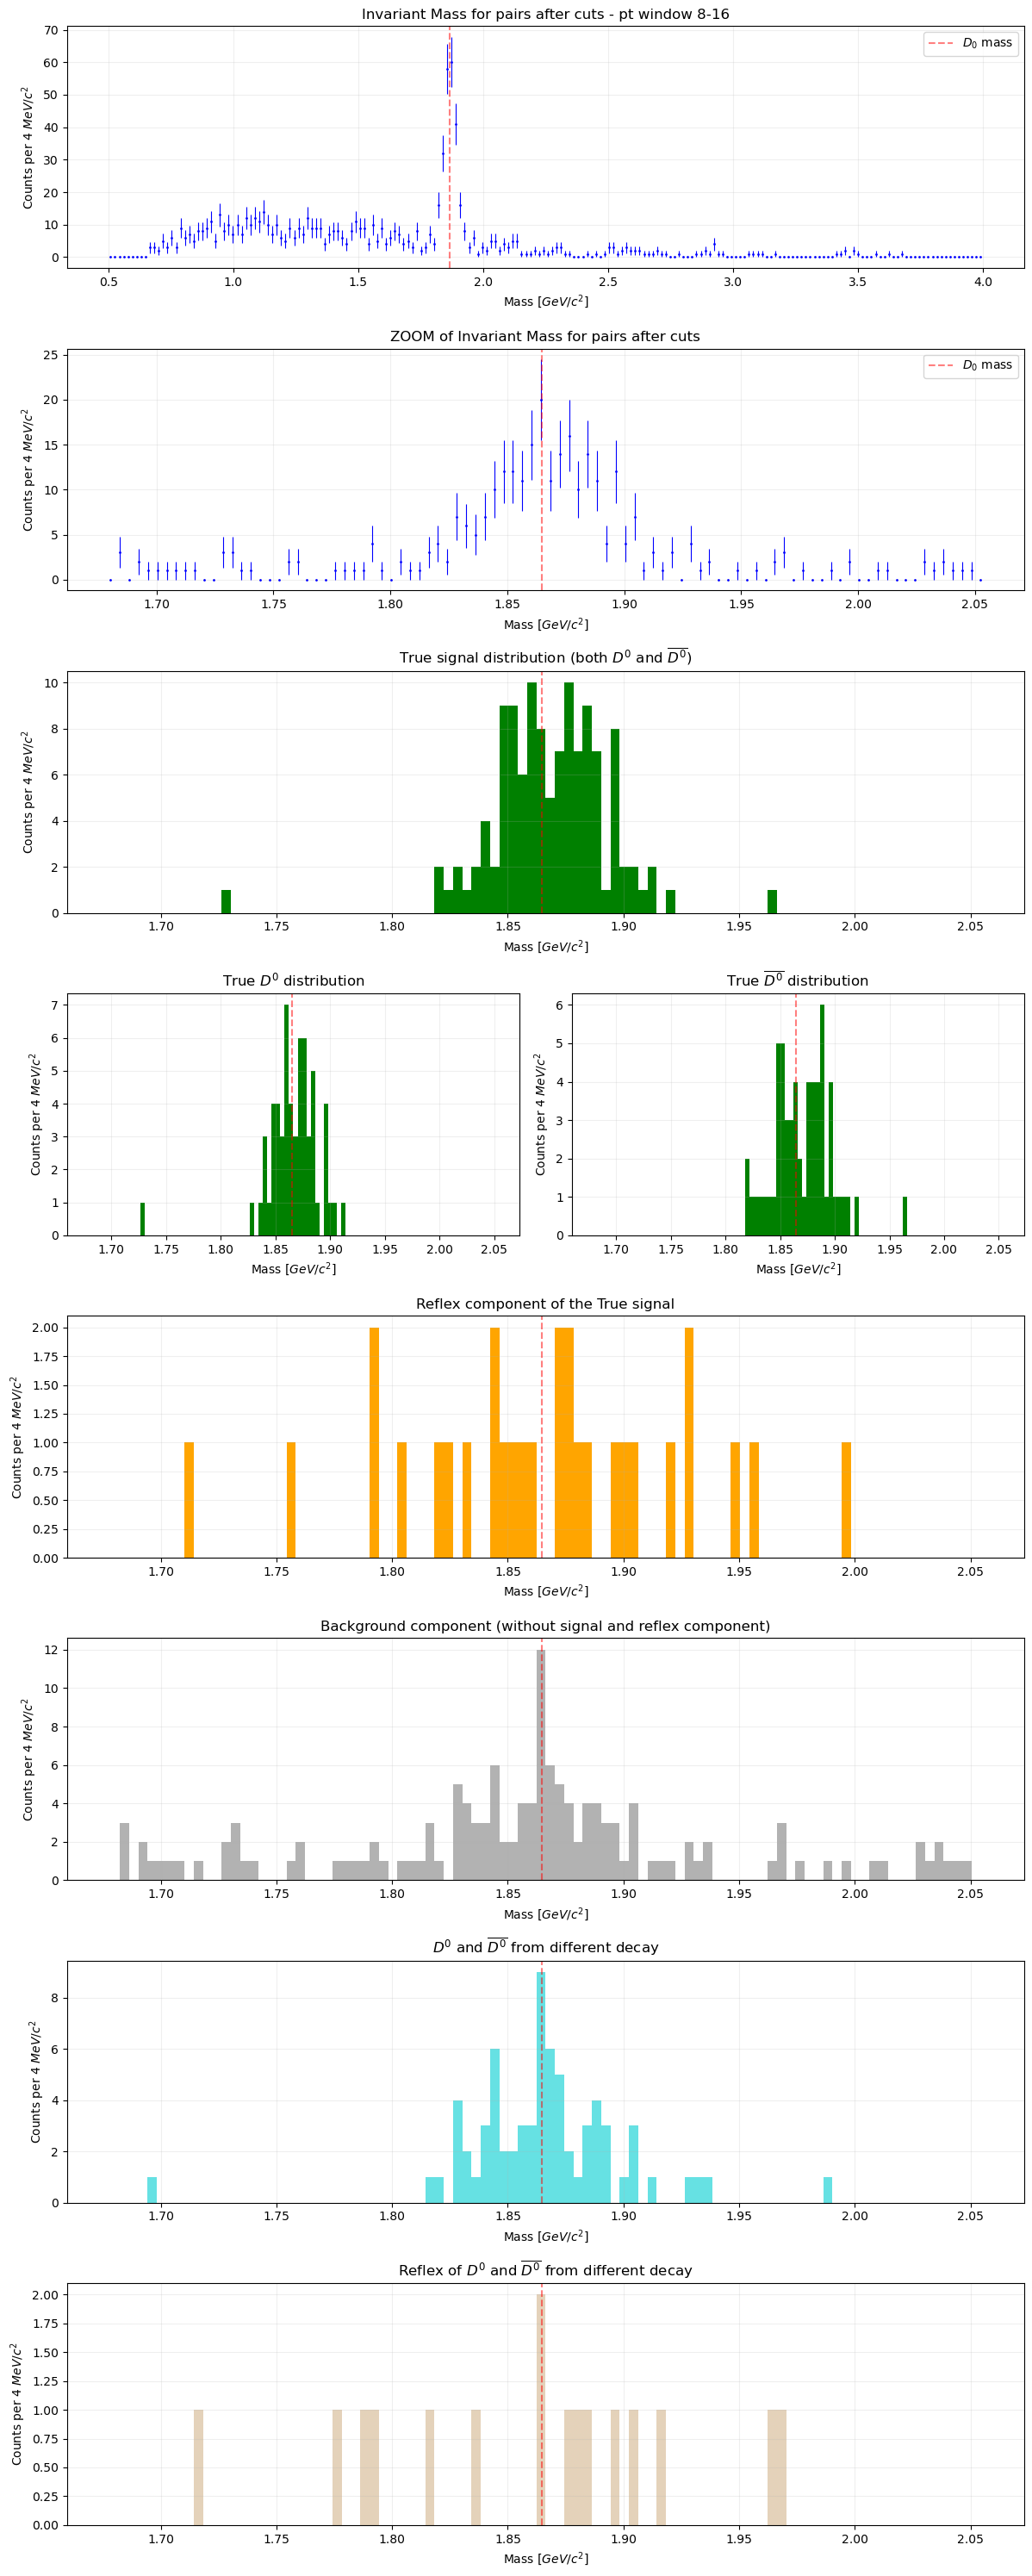

In [180]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0     # for zoom
N_BINS = 100
binsize = 0.004  # GeV/c^2

# Layout con due colonne
zones = [
    ["total", "total"],
    ["total_zoom", "total_zoom"],
    ["signal", "signal"],           # both D0 and anti_D0
    ["D0", "anti_D0"],
    ["reflex", "reflex"],
    ["BG","BG"],
    ["fake_signal", "fake_signal"],
    ["fake_reflex", "fake_reflex"]
]

# Creazione della figura usando subplot_mosaic
fig, axs = plt.subplot_mosaic(
    zones,
    figsize=(12, 30),
    gridspec_kw={"width_ratios": [1, 1]}
)

# ----------------------- DATA PLOT -----------------------------------------------
# PLOT OF ALL PAIRS
counts, bin_edges = np.histogram(mass_data_hyp, bins=2*N_BINS, range=(0.5, 4))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs["total"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue', elinewidth=0.8)
axs["total"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs["total"].set_xlabel("Mass [$GeV/c^2$]")
axs["total"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["total"].set_title(f"Invariant Mass for pairs after cuts - pt window {pt_windows[i_window]}")
axs["total"].set_xticks( np.arange(0.5, 4.1, 0.5) )
axs["total"].legend()
axs["total"].grid(alpha=0.2)

# ZOOM OF ALL PAIRS
counts, bin_edges = np.histogram(mass_data_hyp, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs["total_zoom"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue', elinewidth=0.8)
axs["total_zoom"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs["total_zoom"].set_xlabel("Mass [$GeV/c^2$]")
axs["total_zoom"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["total_zoom"].set_title("ZOOM of Invariant Mass for pairs after cuts")
#axs["total_zoom"].set_xticks( np.arange(1.5, 2.2, 0.05) )
axs["total_zoom"].legend()
axs["total_zoom"].grid(alpha=0.2)

# -------------------------- TRUE SIGNAL MC -------------------------------------------------
# TRUE SIGNAL
axs["signal"].hist( mass_true_signal, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='green')
axs["signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["signal"].set_xlabel("Mass [$GeV/c^2$]")
axs["signal"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["signal"].set_title("True signal distribution (both $D^0$ and $\overline{{D^0}}$)")
axs["signal"].grid(alpha=0.2)

# only D0
axs["D0"].hist( mass_data_true_d0, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='green')
axs["D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["D0"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["D0"].set_title("True $D^0$ distribution")
axs["D0"].grid(alpha=0.2)

# only anti_D0
axs["anti_D0"].hist( mass_data_true_anti_d0, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='green')
axs["anti_D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["anti_D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["anti_D0"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["anti_D0"].set_title("True $\overline{{D^0}}$ distribution")
axs["anti_D0"].grid(alpha=0.2)

# ----------------------- REFLEX OF TRUE SIGNAL -----------------------------------------
# reflex component of the true signal
axs["reflex"].hist( reflex_data, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='orange')
axs["reflex"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["reflex"].set_xlabel("Mass [$GeV/c^2$]")
axs["reflex"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["reflex"].set_title("Reflex component of the True signal")
axs["reflex"].grid(alpha=0.2)

# ----------------------------------- BG --------------------------------------------------
axs["BG"].hist(mass_bg_all, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='gray', alpha=0.6)
axs["BG"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["BG"].set_xlabel("Mass [$GeV/c^2$]")
axs["BG"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["BG"].set_title("Background component (without signal and reflex component)")
axs["BG"].grid(alpha=0.2)

# ----------------------- D0 and anti-D0 from other decays ('FAKE SIGNAL') -------------------
# plot of the D0 that does not come from our decay pi+ka
axs["fake_signal"].hist(mass_fake_signal, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='darkturquoise', alpha=0.6)
axs["fake_signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["fake_signal"].set_xlabel("Mass [$GeV/c^2$]")
axs["fake_signal"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["fake_signal"].set_title("$D^0$ and $\overline{{D^0}}$ from different decay")
axs["fake_signal"].grid(alpha=0.2)

# --------------------------- REFLEX OF FAKE SIGNAL ----------------------------------------
axs["fake_reflex"].hist(mass_fake_reflex, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS), color='tan', alpha=0.6)
axs["fake_reflex"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["fake_reflex"].set_xlabel("Mass [$GeV/c^2$]")
axs["fake_reflex"].set_ylabel(f"Counts per {binsize*1000:.0f} $MeV/c^2$")
axs["fake_reflex"].set_title("Reflex of $D^0$ and $\overline{{D^0}}$ from different decay")
axs["fake_reflex"].grid(alpha=0.2)


#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

In [181]:
print(f"Number of signal particles: ", len(mass_true_signal) )
print(f"Number of reflex particles: ", len(reflex_data) )

Number of signal particles:  120
Number of reflex particles:  29


#### INFO ON THE CUTS and on the $p_T$ window

In [182]:
print(f"Let's confront signal before and after cuts + zoom in pt slice:\n")
print(f"Total D0 before cuts:               {d0_tot}")
print(f"Total D0 found after cuts:          {d0_tot_cutted_pt} ---> {d0_tot_cutted_pt / d0_tot * 100:.2f}%\n")
print(f"Total anti-D0 before cuts:          {anti_d0_tot}")
print(f"Total anti-D0 found after cuts:     {anti_d0_tot_cutted_pt} ---> {anti_d0_tot_cutted_pt / anti_d0_tot * 100:.2f}%\n")
print(f"Total signal before cuts:           {signal_tot}")
print(f"Total signal found after cuts:      {signal_tot_cutted_pt} ---> {signal_tot_cutted_pt / signal_tot * 100:.2f}%\n")
print(f"Total background found after cuts:  ---> {num_bg_pairs_cutted_pt / num_bg_pairs * 100:.2f}%\n" )

print("LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL):\n")

sigma_guess = 0.015
mass_window = (m_d0 - 3*sigma_guess, m_d0 + 3*sigma_guess)

# --- signal ---
signal_in_window = mass_true_signal[(mass_true_signal > mass_window[0]) & (mass_true_signal < mass_window[1])]

# --- background ---
background = np.concatenate([
    df.loc[mask_background_cutted_pt, "inv_mass"].values,
    df.loc[mask_background_cutted_pt, "anti_mass"].values
])
background_in_window = background[ (background > mass_window[0]) & (background < mass_window[1]) ]

S = len(signal_in_window)
B = len(background_in_window)

print(
    f"Signal found in the interval:     {S}\n"
    f"Background found in the interval: {B}\n\n"
    f"Signal fraction in interval:     {S / (S + B) * 100:.2f}%\n"
    f"Significance (S/√(S+B)):          {S / np.sqrt(S + B):.2f}\n"
    f"Ratio (S/B):                      {S / B:.2f}"
)


Let's confront signal before and after cuts + zoom in pt slice:

Total D0 before cuts:               11611
Total D0 found after cuts:          60 ---> 0.52%

Total anti-D0 before cuts:          12159
Total anti-D0 found after cuts:     60 ---> 0.49%

Total signal before cuts:           23770
Total signal found after cuts:      120 ---> 0.50%

Total background found after cuts:  ---> 0.00%

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL):

Signal found in the interval:     113
Background found in the interval: 122

Signal fraction in interval:     48.09%
Significance (S/√(S+B)):          7.37
Ratio (S/B):                      0.93


---

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS FIT</b></span></center>

We try to fit the invariant mass histogram using:
* a gaussian for the signal
* a gaussian for the reflex component
* a linear/parablic/exponential function for the background

We do it in a way so that the ratio $N_1/N_2$ between the two gaussian is fixed, and the parameter $k$ is free:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Reflex} + \text{Signal} + \frac{N_3}{N_2} \text{Reflex-Fakes} \right) + \text{Background}
$$

which means, in the linear background example:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Gaussian1} + \text{Gaussian2} + \frac{N_3}{N_2} \text{Gaussian3} \right) + a \cdot x +b
$$

In [183]:
reflex_data_tot = np.concatenate( [reflex_data, mass_fake_reflex] )

### FINDING RATIO $N_1/N_2$
Let's fit the data given by signal + reflex component (using MC info).

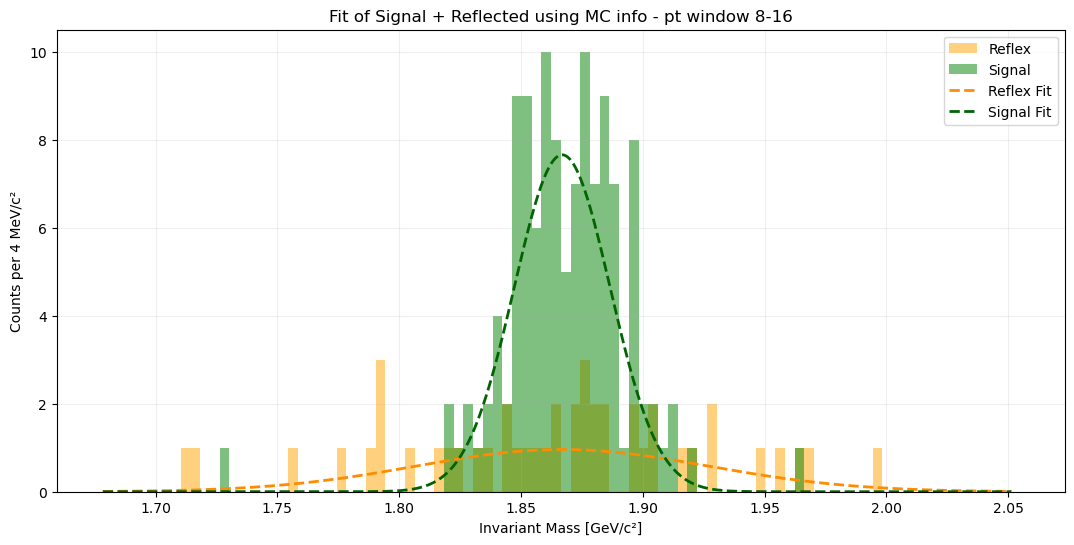


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8669       0.0197        0.378
Reflex             1.8670       0.0600        0.144 

Ratio N1/N2 (reflex/signal):                  0.382 


In [184]:
# ======================================== FINDING RATIO N1/N2 ==========================================

# --- Fit function: Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
binsize = 0.004  # GeV/c^2
# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# ------------------------------------------------------------------
# Histogram of TRUE signal and TRUE reflected components
# signal:
signal_data = mass_true_signal

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,6))
# ------- reflex component:
reflex_counts, reflex_edges, _ = ax.hist(reflex_data_tot, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), 
                                         range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
# poisson errors:
sigma_reflex_hist = np.sqrt(reflex_counts)
sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), 
                                     range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
sign_params = sign_fit_res[0]
mu_sign, sigma_sign = sign_params[1], sign_params[2]
k_sign = sign_params[0]
# ----
reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
reflex_params = reflex_fit_res[0]
mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
k_reflex = reflex_params[0]

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.0f} MeV/c²")
ax.set_title(f"Fit of Signal + Reflected using MC info - pt window {pt_windows[i_window]}")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# PRINT:
ratio_from_fit = k_reflex/k_sign
print("\n================ FIT RESULTS =================")

print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
print("-"*48)
print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
print(f"{'Reflex':<12} {mu_reflex:>12.4f} {sigma_reflex:>12.4f} {k_reflex:>12.3f} \n")

print(f"Ratio N1/N2 (reflex/signal):   {ratio_from_fit:>20.3f} ")

### FINDING RATIO $N_3/N_2$
Let's fit the data given by signal + reflex component (using MC info).

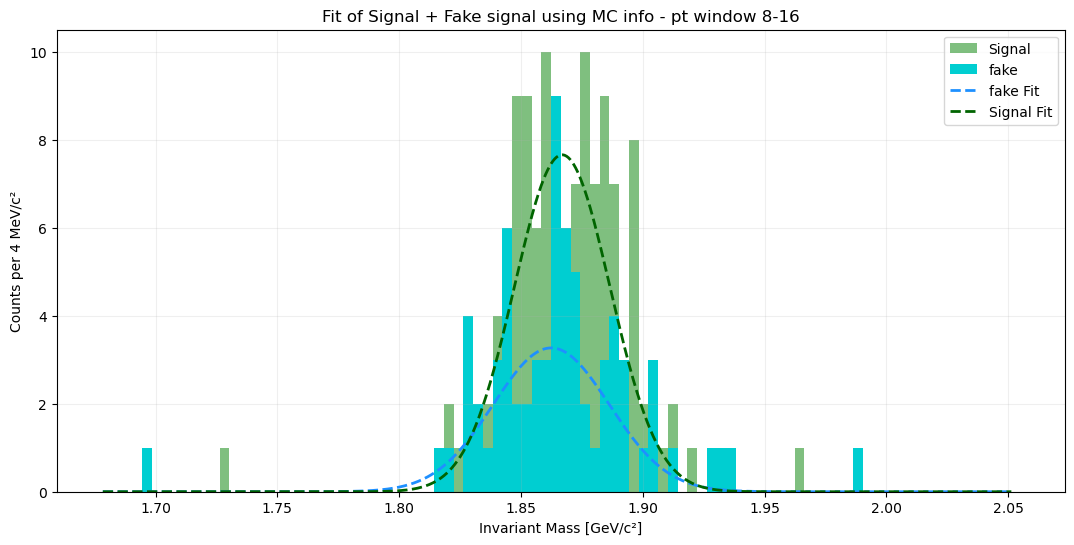


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8669       0.0197        0.378
fake               1.8624       0.0238        0.195 

Ratio N3/N2 (fake/signal):                  0.517 


In [185]:
# ======================================== FINDING RATIO N3/N2 ==========================================

# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# ------------------------------------------------------------------
# Histogram of TRUE signal and TRUE reflected components

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,6))
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), 
                                     range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros
# ------- fake component:
fake_counts, fake_edges, _ = ax.hist(mass_fake_signal, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), 
                                     range=(MIN_MASS, MAX_MASS), label='fake', color='darkturquoise')
fake_centers = (fake_edges[:-1] + fake_edges[1:]) / 2.0
# poisson errors:
sigma_fake_hist = np.sqrt(fake_counts)
sigma_fake_hist = np.clip(sigma_fake_hist, 1, None)  # avoid zeros

# FIT:

# sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
#                             p0 = [k_param, 
#                                   gauss_params[0], gauss_params[1]
#                                  ]
#                         )
# sign_params = sign_fit_res[0]
# mu_sign, sigma_sign = sign_params[1], sign_params[2]
# k_sign = sign_params[0]

# ----
fake_fit_res = curve_fit( fit_gauss_mc, xdata = fake_centers, ydata = fake_counts, sigma = sigma_fake_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
fake_params = fake_fit_res[0]
mu_fake, sigma_fake = fake_params[1], fake_params[2]
k_fake = fake_params[0]

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_fake, mu_fake, sigma_fake), '--', color='dodgerblue', linewidth=2, label='fake Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.0f} MeV/c²")
ax.set_title(f"Fit of Signal + Fake signal using MC info - pt window {pt_windows[i_window]}")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# PRINT:
ratio_from_fit_2 = k_fake/k_sign
print("\n================ FIT RESULTS =================")

print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
print("-"*48)
print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
print(f"{'fake':<12} {mu_fake:>12.4f} {sigma_fake:>12.4f} {k_fake:>12.3f} \n")

print(f"Ratio N3/N2 (fake/signal):   {ratio_from_fit_2:>20.3f} ")

---

### INVARIANT MASS FIT

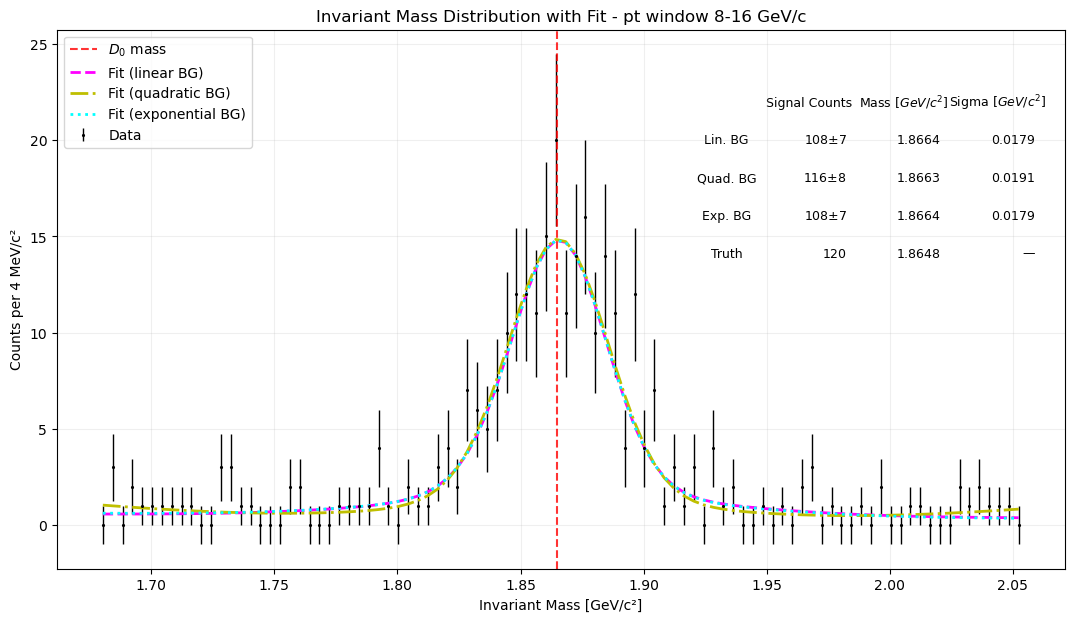

In [186]:
# ======================== FIT FUNCTIONS ===============================

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
binsize = 0.004  # GeV/c^2
ratio = ratio_from_fit   # fixed ratio from previous fit N_reflex/N_signal
ratio2 = ratio_from_fit_2

# --- Fit function: 1 free Gaussian (signal) + 1 FIXED Gaussian (reflex) + linear background ---
def fit_function_lin(x, k, mu1, sigma1, a, b):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    fake_part    = norm.pdf(x, loc=mu_fake,   scale=sigma_fake)
    background   = a*x + b
    return k * ( ratio*reflex_part + signal_part + ratio2*fake_part ) + background

# --- Fit function with quadratic background ---
def fit_function_quad(x, k, mu1, sigma1, a2, a1, a0):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    fake_part    = norm.pdf(x, loc=mu_fake,   scale=sigma_fake)
    background   = a2*x**2 + a1*x + a0
    return k * ( ratio*reflex_part + signal_part + ratio2*fake_part ) + background

# --- Fit function with exponential background ---
def fit_function_exp(x, k, mu1, sigma1, A, lamb):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    fake_part    = norm.pdf(x, loc=mu_fake,   scale=sigma_fake)
    background   = A * np.exp(lamb * x)
    return k * ( ratio*reflex_part + signal_part + ratio2*fake_part ) + background



# ============================= DATA AND HISTOGRAM ==========================================

mass_data_d0_hyp         = df.loc[mask_d0_hyp,     "inv_mass"].values
mass_data_anti_d0_hyp    = df.loc[mask_anti_d0_hyp, "anti_mass"].values

mass_data_both_hyp_inv   = df.loc[mask_both_hyp,   "inv_mass"].values
mass_data_both_hyp_anti  = df.loc[mask_both_hyp,   "anti_mass"].values

data = np.concatenate([
    mass_data_d0_hyp,
    mass_data_anti_d0_hyp,
    mass_data_both_hyp_inv,
    mass_data_both_hyp_anti
])

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,7))
both_counts, both_edges = np.histogram(data, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS))
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)
# plot:
ax.errorbar(both_centers, both_counts, yerr=sigma_hist, fmt='.', markersize=2.5, color='black', label='Data', elinewidth=1)
ax.axvline(x=m_d0, color="red", ls='--', label=r"$D_0$ mass", alpha=0.8)



# =========================================== FIT =========================================

# Initial parameter guesses
k_param       = 100
signal_params = [m_d0, 0.02]
back_params   = [133, 1000]
quad_back_params = [0.0, 0.0, 25]
e = [600000, 750, 25, 25, 25, 25]
exp_back_params  = [e[i_window], -0.01]  # as first value, put 25 for pt in [3-16], 750 in [1.5-3], 14000 for [0-1.5]

# LINEAR FIT:
both_fit_res = curve_fit(
    f       = fit_function_lin,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,                # 0: k
        signal_params[0],       # 1: mu1
        signal_params[1],       # 2: sigma1
        back_params[0],         # 3: a
        back_params[1]          # 4: b
    ]
)
both_params =     both_fit_res[0]
both_params_err = np.sqrt(np.diag(both_fit_res[1])) # fit errors
# k_fit, mu1, sigma1, a_fit, b_fit = both_params

# QUADRATIC FIT:
quad_fit_res = curve_fit(
    f       = fit_function_quad,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,
        signal_params[0],
        signal_params[1],
        *quad_back_params
    ]
)
quad_params =     quad_fit_res[0]
quad_params_err = np.sqrt(np.diag(quad_fit_res[1]))  # fit errors

# EXPONENTIAL FIT:
exp_fit_res = curve_fit(
    f       = fit_function_exp,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,
        signal_params[0],
        signal_params[1],
        *exp_back_params
    ]
)
exp_params =     exp_fit_res[0]
exp_params_err = np.sqrt(np.diag(exp_fit_res[1]))  # fit errors


# =================== PLOT FITTED CURVES ========================================

# --- Plot fitted curves ---
ax.plot( both_centers, fit_function_lin(both_centers, *both_params),
         color='magenta', linestyle='dashed', linewidth=2., label='Fit (linear BG)'
)

ax.plot( both_centers, fit_function_quad(both_centers, *quad_params),
         color='y', linestyle='dashdot', linewidth=2, label='Fit (quadratic BG)'
)

ax.plot( both_centers, fit_function_exp(both_centers, *exp_params),
         color='cyan', linestyle='dotted', linewidth=2, label='Fit (exponential BG)'
)


# ==================== RESULTS ===============================================

def signal_yield_from_fit(k, mu, sigma, binsize, xmin, xmax):
    integral = norm.cdf(xmax, mu, sigma) - norm.cdf(xmin, mu, sigma)
    return (k * integral) / binsize
    
k_lin, mu_lin, sigma_lin, *_ = both_params
N_sig_lin = signal_yield_from_fit( k_lin, mu_lin, sigma_lin, binsize, MIN_MASS, MAX_MASS )

k_quad, mu_quad, sigma_quad, *_ = quad_params
N_sig_quad = signal_yield_from_fit( k_quad, mu_quad, sigma_quad, binsize, MIN_MASS, MAX_MASS )

k_exp, mu_exp, sigma_exp, *_ = exp_params
N_sig_exp = signal_yield_from_fit( k_exp, mu_exp, sigma_exp, binsize, MIN_MASS, MAX_MASS )


# ==================== FIT ERRORS ==========================================
# let's extrapolate the fit error in the counts of signal particles

count_err_lin  = signal_yield_from_fit( both_params_err[0], mu_lin, sigma_lin, binsize, MIN_MASS, MAX_MASS)
count_err_quad = signal_yield_from_fit( quad_params_err[0], mu_quad, sigma_quad, binsize, MIN_MASS, MAX_MASS )
count_err_exp  = signal_yield_from_fit( exp_params_err[0], mu_exp, sigma_exp, binsize, MIN_MASS, MAX_MASS )


# ======================= TABLE INSIDE PLOT =======================

cell_text = [
    [f"{N_sig_lin:.0f}"+r"$\pm$"+f"{count_err_lin:.0f}",  f"{mu_lin:.4f}",  f"{sigma_lin:.4f}"],
    [f"{N_sig_quad:.0f}"+r"$\pm$"+f"{count_err_quad:.0f}", f"{mu_quad:.4f}", f"{sigma_quad:.4f}"],
    [f"{N_sig_exp:.0f}"+r"$\pm$"+f"{count_err_exp:.0f}",  f"{mu_exp:.4f}",  f"{sigma_exp:.4f}"],
    [f"{len(mass_true_signal)}",       f"{m_d0:.4f}",    "—"]
]

row_labels = [
    "Lin. BG",
    "Quad. BG",
    "Exp. BG",
    "Truth"
]

col_labels = [
    r"Signal Counts",
    r"Mass [$GeV/c^2$]",
    r"Sigma [$GeV/c^2$]"
]

table = ax.table(
    cellText   = cell_text,
    rowLabels  = row_labels,
    colLabels  = col_labels,
    colLoc     = "center",
    rowLoc     = "center",
    bbox       = [0.70, 0.55, 0.28, 0.35],     # bbox = [x0, y0, width, height] in axes coordinates (0–1)
    edges      = "open"
)
table.auto_set_font_size(False)
table.set_fontsize(9)


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.0f} MeV/c²")
ax.set_title(f"Invariant Mass Distribution with Fit - pt window {pt_windows[i_window]} GeV/c")
ax.legend(loc='upper left')
ax.grid(alpha=0.2)
plt.draw()   # force the layout before saving (for estetics)
plt.savefig(f"images/mass_fit_pt{pt_windows[i_window]}.png")
plt.show()

In [187]:
# ================================ PRINT RESULTS ==========================================

print("\n================ FIT RESULTS =================")

print(f"{'Fit':<12} {'N_signal':>10} {'ΔN':>10} {'mu':>12} {'sigma':>12}")
print("-"*60)

print(f"{'Linear':<12} {N_sig_lin:>10.0f} {count_err_lin:>10.0f} {mu_lin:>12.6f} {sigma_lin:>12.6f}")
print(f"{'Quadratic':<12} {N_sig_quad:>10.0f} {count_err_quad:>10.0f} {mu_quad:>12.6f} {sigma_quad:>12.6f}")
print(f"{'Exponential':<12} {N_sig_exp:>10.0f} {count_err_exp:>10.0f} {mu_exp:>12.6f} {sigma_exp:>12.6f}")
print(f"{'truth':<12} {len(mass_true_signal):>10.0f} {'—':>10} {m_d0:>12.6f}")


================ FIT RESULTS =================
Fit            N_signal         ΔN           mu        sigma
------------------------------------------------------------
Linear              108          7     1.866353     0.017922
Quadratic           116          8     1.866306     0.019078
Exponential         108          7     1.866383     0.017949
truth               120          —     1.864840


### OVERLAYING OUR FIT WITH TRUE MC DATA

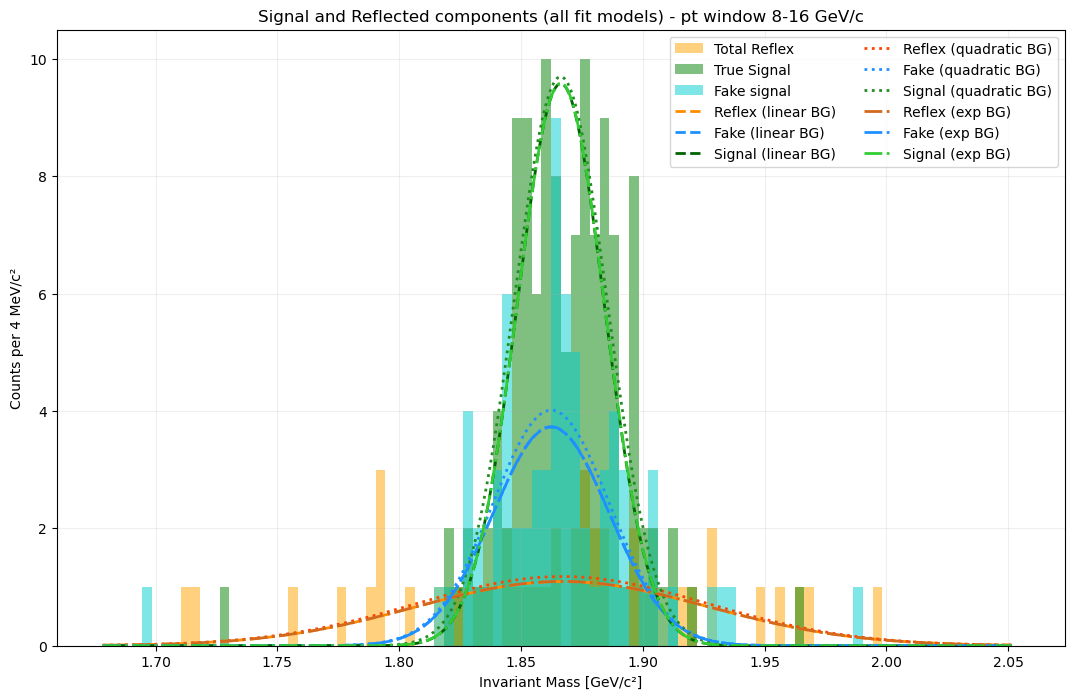

In [188]:
# ========================= OVERLAYING OUR FIT WITH TRUE MC DATA =========================



fig, ax = plt.subplots(figsize=(13, 8))

# ===================== DATA =====================
# already defines reflex_data_tot and signal_data

# ===================== HISTOGRAMS =====================

ax.hist( reflex_data_tot, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS),
    color='orange', alpha=0.5, label='Total Reflex' )

ax.hist( signal_data, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS),
    color='green', alpha=0.5, label='True Signal' )

ax.hist( mass_fake_signal, bins=np.arange(MIN_MASS, MAX_MASS+binsize,binsize), range=(MIN_MASS, MAX_MASS),
    color='darkturquoise', alpha=0.5, label='Fake signal' )

# ===================== FITTED CURVES ===================

x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)

# --- Linear BG fit ---
ax.plot( x_fit, k_lin * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
    '--', color='darkorange', linewidth=2, label='Reflex (linear BG)' )

ax.plot( x_fit, k_lin * ratio2 * norm.pdf(x_fit, mu_fake, sigma_fake),
    '--', color='dodgerblue', linewidth=2, label='Fake (linear BG)' )

ax.plot( x_fit, k_lin * norm.pdf(x_fit, mu_lin, sigma_lin),
    '--', color='darkgreen', linewidth=2, label='Signal (linear BG)' )

# --- Quadratic BG fit ---
ax.plot( x_fit, k_quad * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
    ':', color='orangered', linewidth=2, label='Reflex (quadratic BG)' )

ax.plot( x_fit, k_quad * ratio2 * norm.pdf(x_fit, mu_fake, sigma_fake),
    ':', color='dodgerblue', linewidth=2, label='Fake (quadratic BG)' )

ax.plot( x_fit, k_quad * norm.pdf(x_fit, mu_quad, sigma_quad),
    ':', color='forestgreen', linewidth=2, label='Signal (quadratic BG)' )

# --- Exponential BG fit ---
ax.plot( x_fit, k_exp * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
    '-.', color='chocolate', linewidth=2, label='Reflex (exp BG)' )

ax.plot( x_fit, k_exp * ratio2 * norm.pdf(x_fit, mu_fake, sigma_fake),
    '-.', color='dodgerblue', linewidth=2, label='Fake (exp BG)' )

ax.plot( x_fit, k_exp * norm.pdf(x_fit, mu_exp, sigma_exp),
    '-.', color='limegreen', linewidth=2, label='Signal (exp BG)' )

# ===================== STYLE =====================

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.0f} MeV/c²")
ax.set_title(f"Signal and Reflected components (all fit models) - pt window {pt_windows[i_window]} GeV/c")
ax.legend(ncol=2, fontsize=10)
ax.grid(alpha=0.2)

#plt.tight_layout()
plt.draw()
plt.savefig(f"images/all_components_pt{pt_windows[i_window]}.png")
plt.show()